# 🏦 AI Financial Fragility Detector
## Early Warning Signals in Regional Banks

---

**Project Overview:** This notebook builds an AI-powered early warning system that detects structural financial weakness in regional banks before stress becomes visible in market prices. It combines:
1. **Structured financial vulnerability modeling** (4 key ratios)
2. **Unstructured linguistic stress measurement** (NLP on 10-K filings)
3. **Normalized fragility scoring** across institutions
4. **Backtesting** against known bank failures (SVB, Signature Bank, First Republic, etc.)

**Data Sources:**
- FDIC BankFind API — quarterly financial data for all FDIC-insured institutions
- FDIC Failed Bank List — ground truth for bank distress events
- SEC EDGAR — 10-K filings for textual risk analysis
- Yahoo Finance — stock price data for drawdown analysis

**Required Libraries:** `pandas`, `numpy`, `requests`, `beautifulsoup4`, `nltk`, `scikit-learn`, `matplotlib`, `seaborn`, `yfinance`, `plotly`

---
## Cell 1 — Install Required Libraries
Install all dependencies. Run this cell once.

In [1]:
# =============================================================================
# CELL 1: Install Required Libraries
# =============================================================================
# Run this cell first to ensure all dependencies are installed.
# If you already have these installed, you can skip this cell.

!pip install pandas numpy requests beautifulsoup4 nltk scikit-learn matplotlib seaborn yfinance plotly lxml html5lib tqdm openpyxl

print("✅ All libraries installed successfully.")

✅ All libraries installed successfully.


---
## Cell 2 — Import Libraries & Configuration
Import all required modules and set global configuration.

In [2]:
# =============================================================================
# CELL 2: Import Libraries & Configuration
# =============================================================================

# --- Data Manipulation ---
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

# --- Web Requests & Parsing ---
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm

# --- NLP ---
import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# --- Machine Learning ---
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Stock Data ---
import yfinance as yf

# --- Configuration ---
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# FDIC API base URL (free, no API key required)
FDIC_API_BASE = "https://api.fdic.gov/banks"

# SEC EDGAR base URL
EDGAR_BASE = "https://efts.sec.gov/LATEST/search-index?q="
EDGAR_FULL_TEXT = "https://efts.sec.gov/LATEST/search-index"
EDGAR_FILING_BASE = "https://www.sec.gov/cgi-bin/browse-edgar"
EDGAR_ARCHIVES = "https://www.sec.gov/Archives/edgar/data"

# Headers for SEC EDGAR (required - they block requests without user agent)
EDGAR_HEADERS = {
    'User-Agent': 'Nikhil Patwal patwal.n@northeastern.edu',  # <-- CHANGE THIS to your name & email
    'Accept-Encoding': 'gzip, deflate',
}

# Create output directory for saved data
os.makedirs('data', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
print("✅ All libraries imported successfully.")
print(f"📅 Notebook run date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ All libraries imported successfully.
📅 Notebook run date: 2026-04-22 18:23


---
## Cell 3 — Define Target Regional Banks

We select 30 regional banks for analysis, including:
- **Known distress cases** (SVB, Signature Bank, First Republic, etc.) for ground truth validation
- **Stable regional banks** as a control group
- Banks spanning different sizes and geographies

Each bank is identified by its **FDIC Certificate Number (CERT)** and **SEC CIK number** for filing lookups.

In [3]:
# =============================================================================
# CELL 3: Define Target Regional Banks
# =============================================================================
# This dictionary maps bank names to their identifiers:
#   - cert: FDIC Certificate Number (for financial data)
#   - ticker: Stock ticker (for price data)
#   - cik: SEC CIK number (for 10-K filings)
#   - failed: Whether the bank experienced distress
#   - failure_date: Date of failure/distress event (if applicable)

TARGET_BANKS = {
    # === FAILED / DISTRESSED BANKS ===
    "Silicon Valley Bank": {
        "cert": 24735, "ticker": "SIVB", "cik": "0000719739",
        "failed": True, "failure_date": "2023-03-10"
    },
    "Signature Bank": {
        "cert": 57053, "ticker": "SBNY", "cik": "0001288854",
        "failed": True, "failure_date": "2023-03-12"
    },
    "First Republic Bank": {
        "cert": 59017, "ticker": "FRC", "cik": "0000809672",
        "failed": True, "failure_date": "2023-05-01"
    },
    "Silvergate Capital": {
        "cert": 27653, "ticker": "SI", "cik": "0001312109",
        "failed": True, "failure_date": "2023-03-08"
    },

    # === STRESSED BUT SURVIVED (significant drawdowns) ===
    "PacWest Bancorp": {
        "cert": 27417, "ticker": "PACW", "cik": "0001102112",
        "failed": False, "failure_date": None
    },
    "Western Alliance Bancorporation": {
        "cert": 19551, "ticker": "WAL", "cik": "0001124804",
        "failed": False, "failure_date": None
    },
    "Zions Bancorporation": {
        "cert": 2270, "ticker": "ZION", "cik": "0000109380",
        "failed": False, "failure_date": None
    },
    "Comerica": {
        "cert": 18613, "ticker": "CMA", "cik": "0000028412",
        "failed": False, "failure_date": None
    },
    "KeyCorp": {
        "cert": 17534, "ticker": "KEY", "cik": "0000091576",
        "failed": False, "failure_date": None
    },

    # === STABLE REGIONAL BANKS (control group) ===
    "U.S. Bancorp": {
        "cert": 6548, "ticker": "USB", "cik": "0000036104",
        "failed": False, "failure_date": None
    },
    "Truist Financial": {
        "cert": 9846, "ticker": "TFC", "cik": "0000092230",
        "failed": False, "failure_date": None
    },
    "M&T Bank": {
        "cert": 501, "ticker": "MTB", "cik": "0000036270",
        "failed": False, "failure_date": None
    },
    "Regions Financial": {
        "cert": 12368, "ticker": "RF", "cik": "0001281761",
        "failed": False, "failure_date": None
    },
    "Huntington Bancshares": {
        "cert": 6560, "ticker": "HBAN", "cik": "0000049196",
        "failed": False, "failure_date": None
    },
    "Citizens Financial Group": {
        "cert": 27389, "ticker": "CFG", "cik": "0000831501",
        "failed": False, "failure_date": None
    },
    "Fifth Third Bancorp": {
        "cert": 6672, "ticker": "FITB", "cik": "0000035527",
        "failed": False, "failure_date": None
    },
    "First Horizon": {
        "cert": 14413, "ticker": "FHN", "cik": "0000036966",
        "failed": False, "failure_date": None
    },
    "Cullen/Frost Bankers": {
        "cert": 5765, "ticker": "CFR", "cik": "0000039263",
        "failed": False, "failure_date": None
    },
    "Glacier Bancorp": {
        "cert": 32831, "ticker": "GBCI", "cik": "0000042682",
        "failed": False, "failure_date": None
    },
    "Columbia Banking System": {
        "cert": 32467, "ticker": "COLB", "cik": "0001166928",
        "failed": False, "failure_date": None
    },
    "Valley National Bancorp": {
        "cert": 10228, "ticker": "VLY", "cik": "0000074260",
        "failed": False, "failure_date": None
    },
    "Synovus Financial": {
        "cert": 7614, "ticker": "SNV", "cik": "0000018349",
        "failed": False, "failure_date": None
    },
    "Webster Financial": {
        "cert": 27847, "ticker": "WBS", "cik": "0000801337",
        "failed": False, "failure_date": None
    },
    "Wintrust Financial": {
        "cert": 27417, "ticker": "WTFC", "cik": "0001015328",
        "failed": False, "failure_date": None
    },
    "Independent Bank Group": {
        "cert": 10386, "ticker": "IBTX", "cik": "0001564618",
        "failed": False, "failure_date": None
    },
    "Heartland BancCorp": {
        "cert": 25851, "ticker": "HTLF", "cik": "0000764038",
        "failed": False, "failure_date": None
    },
    "Renasant Corporation": {
        "cert": 10676, "ticker": "RNST", "cik": "0000715072",
        "failed": False, "failure_date": None
    },
    "Prosperity Bancshares": {
        "cert": 16101, "ticker": "PB", "cik": "0000891478",
        "failed": False, "failure_date": None
    },
    "South State Corporation": {
        "cert": 12430, "ticker": "SSB", "cik": "0000764478",
        "failed": False, "failure_date": None
    },
    "Pinnacle Financial Partners": {
        "cert": 35039, "ticker": "PNFP", "cik": "0001115055",
        "failed": False, "failure_date": None
    },
}

# Convert to DataFrame for easy reference
banks_df = pd.DataFrame.from_dict(TARGET_BANKS, orient='index')
banks_df.index.name = 'bank_name'
banks_df = banks_df.reset_index()

print(f"✅ Defined {len(TARGET_BANKS)} target banks")
print(f"   - Failed/Distressed: {banks_df['failed'].sum()}")
print(f"   - Stable/Survived:   {(~banks_df['failed']).sum()}")
print()
print(banks_df[['bank_name', 'cert', 'ticker', 'failed']].to_string(index=False))

✅ Defined 30 target banks
   - Failed/Distressed: 4
   - Stable/Survived:   26

                      bank_name  cert ticker  failed
            Silicon Valley Bank 24735   SIVB    True
                 Signature Bank 57053   SBNY    True
            First Republic Bank 59017    FRC    True
             Silvergate Capital 27653     SI    True
                PacWest Bancorp 27417   PACW   False
Western Alliance Bancorporation 19551    WAL   False
           Zions Bancorporation  2270   ZION   False
                       Comerica 18613    CMA   False
                        KeyCorp 17534    KEY   False
                   U.S. Bancorp  6548    USB   False
               Truist Financial  9846    TFC   False
                       M&T Bank   501    MTB   False
              Regions Financial 12368     RF   False
          Huntington Bancshares  6560   HBAN   False
       Citizens Financial Group 27389    CFG   False
            Fifth Third Bancorp  6672   FITB   False
                  F

---
## Cell 4 — Pull Quarterly Financial Data from FDIC API

This cell downloads quarterly financial data (balance sheet, income statement, capital ratios) from the FDIC BankFind API for all target banks across a 5-year window (2018–2023).

**No API key required.** The FDIC API is free and publicly accessible.

The key financial fields we pull:
- `ASSET` — Total Assets
- `LIAB` — Total Liabilities
- `EQ` — Total Equity Capital
- `DEP` / `DEPDOM` / `DEPUNINS` — Deposits (total, domestic, uninsured)
- `INTINC` / `EINTEXP` — Interest Income / Interest Expense
- `NETINC` / `PTAXNETINC` — Net Income / Pre-tax Net Income
- `LNLSNET` — Net Loans & Leases
- `CHBAL` — Cash & Balances Due
- `SC` — Total Securities
- `ROA` / `ROE` — Return on Assets / Equity
- `NIMY` — Net Interest Margin

In [4]:
# =============================================================================
# CELL 4: Pull Quarterly Financial Data from FDIC API
# =============================================================================
# FIXED: Correct FDIC API URL format.
# The FDIC API uses Lucene query syntax for filters.
# - No quotes around numeric date ranges
# - Format: REPDTE:[20180331 TO 20231231]
# - Limit must be set high enough (default is only 10 records!)
# - Each CERT + REPDTE combo = one record

def fetch_fdic_financials(cert_number, start_date="20180101", end_date="20231231"):
    """
    Fetch quarterly financial data for a single bank from FDIC API.
    
    Parameters:
        cert_number (int): FDIC Certificate Number
        start_date (str): Start date in YYYYMMDD format
        end_date (str): End date in YYYYMMDD format
    
    Returns:
        pd.DataFrame: Quarterly financial data for the bank
    """
    # Fields we need for ratio computation
    fields = ",".join([
        "CERT", "REPDTE", "NAMEFULL", "ASSET", "LIAB", "EQ", "EQTOT",
        "DEP", "DEPDOM", "DEPUNINS", "DEPINS", "DEPFOR", "DEPIDOM",
        "INTINC", "EINTEXP", "NETINC", "PTAXNETINC", "NOIJ",
        "LNLSNET", "LNLSGR", "LNATRES",
        "CHBAL", "SC", "FREPO", "TRADE",
        "ROA", "ROE", "NIMY", "NIM",
        "NONII", "NONIX",
        "NUMEMP", "OFFDOM",
        "BKCLASS", "STALP", "CITY",
        "RBC1AAJ", "RBCRWAJ",
        "IDT1CER", "IDT1RWAJR",
        "COREDEP", "LNLSDEPR",
        "NCLNLSR", "NTLNLSR", "ELNATR",
        "P3ASSET", "P9ASSET", "P3LTOT", "P9LTOT"
    ])
    
    # CORRECTED URL FORMAT:
    # - No quotes around date range values
    # - Use square brackets for inclusive range: [start TO end]
    # - Set limit=100 to get all quarters (default is only 10!)
    url = (
        f"https://api.fdic.gov/banks/financials?"
        f"filters=CERT%3A{cert_number}%20AND%20REPDTE%3A%5B{start_date}%20TO%20{end_date}%5D"
        f"&fields={fields}"
        f"&sort_by=REPDTE&sort_order=ASC"
        f"&limit=100&offset=0"
    )
    
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        data = response.json()
        
        if 'data' in data and len(data['data']) > 0:
            records = [item['data'] for item in data['data']]
            df = pd.DataFrame(records)
            return df
        else:
            # FALLBACK: Try without date filter (some banks have different date formats)
            fallback_url = (
                f"https://api.fdic.gov/banks/financials?"
                f"filters=CERT%3A{cert_number}"
                f"&fields={fields}"
                f"&sort_by=REPDTE&sort_order=DESC"
                f"&limit=100&offset=0"
            )
            response2 = requests.get(fallback_url, timeout=30)
            response2.raise_for_status()
            data2 = response2.json()
            
            if 'data' in data2 and len(data2['data']) > 0:
                records = [item['data'] for item in data2['data']]
                df = pd.DataFrame(records)
                # Filter date range locally
                df['REPDTE'] = df['REPDTE'].astype(str)
                df = df[(df['REPDTE'] >= start_date) & (df['REPDTE'] <= end_date)]
                if not df.empty:
                    return df
            
            print(f"  ⚠️  No data returned for CERT {cert_number}")
            return pd.DataFrame()
            
    except requests.exceptions.RequestException as e:
        print(f"  ❌ Error fetching CERT {cert_number}: {e}")
        return pd.DataFrame()


# --- Pull data for all target banks ---
print("📥 Fetching FDIC financial data for all target banks...")
print("   (This may take 2-3 minutes due to API rate limits)")
print()

all_financials = []
failed_certs = []

for bank_name, info in tqdm(TARGET_BANKS.items(), desc="Fetching banks"):
    df = fetch_fdic_financials(info['cert'])
    if not df.empty:
        df['bank_name'] = bank_name
        df['ticker'] = info['ticker']
        df['failed'] = info['failed']
        df['failure_date'] = info['failure_date']
        all_financials.append(df)
        print(f"  ✅ {bank_name}: {len(df)} quarters")
    else:
        failed_certs.append((bank_name, info['cert']))
    
    # Respectful rate limiting — FDIC asks for max 10 req/sec
    time.sleep(0.5)

# --- Handle case where no data was returned ---
if len(all_financials) == 0:
    print("\n❌ No data returned from FDIC API for any bank.")
    print("   This might mean:")
    print("   1. The API endpoint has changed")
    print("   2. Network/firewall issues")
    print("   3. The CERT numbers need updating")
    print()
    print("   🔄 FALLBACK: Loading from your downloaded FDIC CSV files instead...")
    print("   Place your downloaded Financial CSV files in the same directory as this notebook.")
    
    # Try loading from local CSV files
    import glob
    csv_files = glob.glob('Financial*.csv') + glob.glob('data/Financial*.csv')
    
    if csv_files:
        frames = []
        for f in csv_files:
            print(f"   Loading {f}...")
            frames.append(pd.read_csv(f))
        financials_df = pd.concat(frames, ignore_index=True)
        
        # Filter to our target CERTs
        target_certs = [info['cert'] for info in TARGET_BANKS.values()]
        financials_df['CERT'] = pd.to_numeric(financials_df['CERT'], errors='coerce')
        financials_df = financials_df[financials_df['CERT'].isin(target_certs)]
        
        # Add bank metadata
        cert_to_info = {}
        for bank_name, info in TARGET_BANKS.items():
            cert_to_info[info['cert']] = {
                'bank_name': bank_name,
                'ticker': info['ticker'],
                'failed': info['failed'],
                'failure_date': info['failure_date']
            }
        
        financials_df['bank_name'] = financials_df['CERT'].map(lambda c: cert_to_info.get(c, {}).get('bank_name', 'Unknown'))
        financials_df['ticker'] = financials_df['CERT'].map(lambda c: cert_to_info.get(c, {}).get('ticker', ''))
        financials_df['failed'] = financials_df['CERT'].map(lambda c: cert_to_info.get(c, {}).get('failed', False))
        financials_df['failure_date'] = financials_df['CERT'].map(lambda c: cert_to_info.get(c, {}).get('failure_date', None))
        
        print(f"\n  ✅ Loaded {len(financials_df)} records from local CSV files")
    else:
        print("   ❌ No local CSV files found either. Please download financial data from:")
        print("      https://banks.data.fdic.gov/bankfind-suite/bulkData/bulkDataDownload")
        financials_df = pd.DataFrame()
else:
    # Combine all banks into a single DataFrame
    financials_df = pd.concat(all_financials, ignore_index=True)

# --- Clean up data types ---
if not financials_df.empty:
    numeric_cols = ['ASSET', 'LIAB', 'EQ', 'DEP', 'DEPDOM', 'DEPUNINS', 'DEPINS',
                    'INTINC', 'EINTEXP', 'NETINC', 'PTAXNETINC', 'LNLSNET',
                    'CHBAL', 'SC', 'FREPO', 'TRADE', 'ROA', 'ROE', 'NIMY',
                    'NOIJ', 'NONII', 'NONIX', 'COREDEP', 'LNLSGR', 'LNATRES',
                    'RBC1AAJ', 'RBCRWAJ', 'P3ASSET', 'P9ASSET', 'P3LTOT', 'P9LTOT',
                    'NCLNLSR', 'NTLNLSR', 'ELNATR', 'NUMEMP', 'OFFDOM',
                    'IDT1CER', 'IDT1RWAJR', 'EQTOT', 'NIM', 'DEPFOR', 'DEPIDOM',
                    'LNLSDEPR']

    for col in numeric_cols:
        if col in financials_df.columns:
            financials_df[col] = pd.to_numeric(financials_df[col], errors='coerce')

    # Parse report date
    financials_df['REPDTE'] = financials_df['REPDTE'].astype(str)
    financials_df['report_date'] = pd.to_datetime(financials_df['REPDTE'], format='%Y%m%d')
    financials_df['year'] = financials_df['report_date'].dt.year
    financials_df['quarter'] = financials_df['report_date'].dt.quarter

    # Save raw data
    financials_df.to_csv('data/fdic_financials_raw.csv', index=False)

    print()
    print(f"✅ Financial data ready!")
    print(f"   Total records: {len(financials_df)}")
    print(f"   Banks covered: {financials_df['bank_name'].nunique()}")
    print(f"   Date range:    {financials_df['report_date'].min().strftime('%Y-%m')} to {financials_df['report_date'].max().strftime('%Y-%m')}")
    print(f"   Saved to:      data/fdic_financials_raw.csv")
    
    if failed_certs:
        print(f"\n  ⚠️  Banks with no data ({len(failed_certs)}):")
        for name, cert in failed_certs:
            print(f"      {name} (CERT: {cert})")
else:
    print("\n❌ No financial data available. Cannot proceed with analysis.")

📥 Fetching FDIC financial data for all target banks...
   (This may take 2-3 minutes due to API rate limits)



Fetching banks:   0%|          | 0/30 [00:00<?, ?it/s]

  ✅ Silicon Valley Bank: 20 quarters


Fetching banks:   3%|▎         | 1/30 [00:01<00:42,  1.47s/it]

  ✅ Signature Bank: 20 quarters


...

  ⚠️  No data returned for CERT 12430


Fetching banks:  97%|█████████▋| 29/30 [00:33<00:01,  1.23s/it]

  ⚠️  No data returned for CERT 35039


Fetching banks: 100%|██████████| 30/30 [00:35<00:00,  1.18s/it]


✅ Financial data ready!
   Total records: 442
   Banks covered: 19
   Date range:    2018-03 to 2023-12
   Saved to:      data/fdic_financials_raw.csv

  ⚠️  Banks with no data (11):
      Silvergate Capital (CERT: 27653)
      Western Alliance Bancorporation (CERT: 19551)
      Comerica (CERT: 18613)
      Cullen/Frost Bankers (CERT: 5765)
      Glacier Bancorp (CERT: 32831)
      Columbia Banking System (CERT: 32467)
      Valley National Bancorp (CERT: 10228)
      Independent Bank Group (CERT: 10386)
      Renasant Corporation (CERT: 10676)
      South State Corporation (CERT: 12430)
      Pinnacle Financial Partners (CERT: 35039)


---
## Cell 5 — Compute Financial Vulnerability Ratios

We compute four key financial ratios that indicate structural vulnerability:

| Ratio | Formula | What It Measures |
|-------|---------|-----------------|
| **Liquidity Ratio** | (Cash + Securities) / Total Deposits | Ability to meet deposit withdrawals |
| **Debt-to-Equity** | Total Liabilities / Total Equity | Leverage and capital adequacy |
| **Interest Coverage** | Net Interest Income / Total Interest Expense | Ability to service debt from core earnings |
| **Loan-to-Deposit Ratio** | Net Loans / Total Deposits | How aggressively the bank lends relative to its funding |

Additionally, we compute supplementary risk indicators:
- **Uninsured Deposit Ratio** — % of deposits that are uninsured (flight risk)
- **Non-Performing Asset Ratio** — past-due loans as % of total assets
- **Return on Assets (ROA)** — profitability signal

In [5]:
# =============================================================================
# CELL 5: Compute Financial Vulnerability Ratios
# =============================================================================

def compute_ratios(df):
    """
    Compute financial vulnerability ratios for each bank-quarter observation.
    
    These ratios are designed to capture structural fragility, not just profitability.
    A bank can be profitable but structurally fragile if its liquidity is thin
    or its deposits are heavily uninsured.
    """
    result = df.copy()
    
    # --- Ratio 1: Liquidity Ratio ---
    # (Cash + Securities + Fed Funds Sold) / Total Deposits
    # Higher = more liquid = less fragile
    result['liquidity_ratio'] = (
        (result['CHBAL'].fillna(0) + result['SC'].fillna(0) + result['FREPO'].fillna(0))
        / result['DEP'].replace(0, np.nan)
    )
    
    # --- Ratio 2: Debt-to-Equity Ratio ---
    # Total Liabilities / Total Equity
    # Higher = more leveraged = more fragile
    result['debt_to_equity'] = (
        result['LIAB'] / result['EQ'].replace(0, np.nan)
    )
    
    # --- Ratio 3: Interest Coverage Ratio ---
    # Net Interest Income / Interest Expense
    # Where Net Interest Income = Interest Income - Interest Expense
    # Higher = better ability to cover interest costs
    result['net_interest_income'] = result['INTINC'].fillna(0) - result['EINTEXP'].fillna(0)
    result['interest_coverage'] = (
        result['net_interest_income'] / result['EINTEXP'].replace(0, np.nan)
    )
    
    # --- Ratio 4: Loan-to-Deposit Ratio ---
    # Net Loans & Leases / Total Deposits
    # Higher = more aggressive lending = potentially less liquid
    result['loan_to_deposit'] = (
        result['LNLSNET'].fillna(0) / result['DEP'].replace(0, np.nan)
    )
    
    # --- Supplementary Risk Indicators ---
    
    # Uninsured Deposit Ratio: Uninsured Deposits / Total Deposits
    # Higher = more flight risk during panic
    result['uninsured_deposit_ratio'] = (
        result['DEPUNINS'].fillna(0) / result['DEP'].replace(0, np.nan)
    )
    
    # Non-Performing Assets Ratio (Past Due 90+ days / Total Assets)
    result['npa_ratio'] = (
        result['P9ASSET'].fillna(0) / result['ASSET'].replace(0, np.nan)
    )
    
    # Core Deposits / Total Deposits (stability indicator)
    result['core_deposit_ratio'] = (
        result['COREDEP'].fillna(0) / result['DEP'].replace(0, np.nan)
    )
    
    # Asset Quality: Loan Loss Reserves / Gross Loans
    result['reserve_ratio'] = (
        result['LNATRES'].fillna(0) / result['LNLSGR'].replace(0, np.nan)
    )
    
    return result


# Apply ratio computation
financials_df = compute_ratios(financials_df)

# --- Display summary statistics for ratios ---
ratio_cols = [
    'liquidity_ratio', 'debt_to_equity', 'interest_coverage', 
    'loan_to_deposit', 'uninsured_deposit_ratio', 'npa_ratio',
    'core_deposit_ratio', 'reserve_ratio', 'ROA', 'ROE'
]

print("📊 Financial Ratio Summary Statistics")
print("=" * 70)
print(financials_df[ratio_cols].describe().round(4).to_string())
print()

# Save ratios
financials_df.to_csv('data/fdic_financials_with_ratios.csv', index=False)
print("✅ Ratios computed and saved to data/fdic_financials_with_ratios.csv")

📊 Financial Ratio Summary Statistics
       liquidity_ratio  debt_to_equity  interest_coverage  loan_to_deposit  uninsured_deposit_ratio  npa_ratio  core_deposit_ratio  reserve_ratio      ROA      ROE
count         442.0000        442.0000           442.0000         442.0000                 442.0000   442.0000            442.0000       442.0000 442.0000 442.0000
mean            0.3494          9.5364             8.6470           0.8292                   0.3684     0.0012              0.9124         0.0124   1.1272  11.4528
std             0.1692          2.7077            22.3047           0.2357                   0.2564     0.0023              0.0815         0.0058   0.9345   9.1053
min             0.0847          4.6650          -339.4205           0.3405                   0.0000     0.0000              0.4910         0.0000  -8.3919 -84.0300
25%             0.2456          7.9704             2.8399           0.7088                   0.1314     0.0000              0.8843         0.00

---
## Cell 6 — Visualize Financial Ratio Trends Over Time

Compare how key ratios evolved for failed vs. stable banks in the years leading up to the 2023 banking crisis.

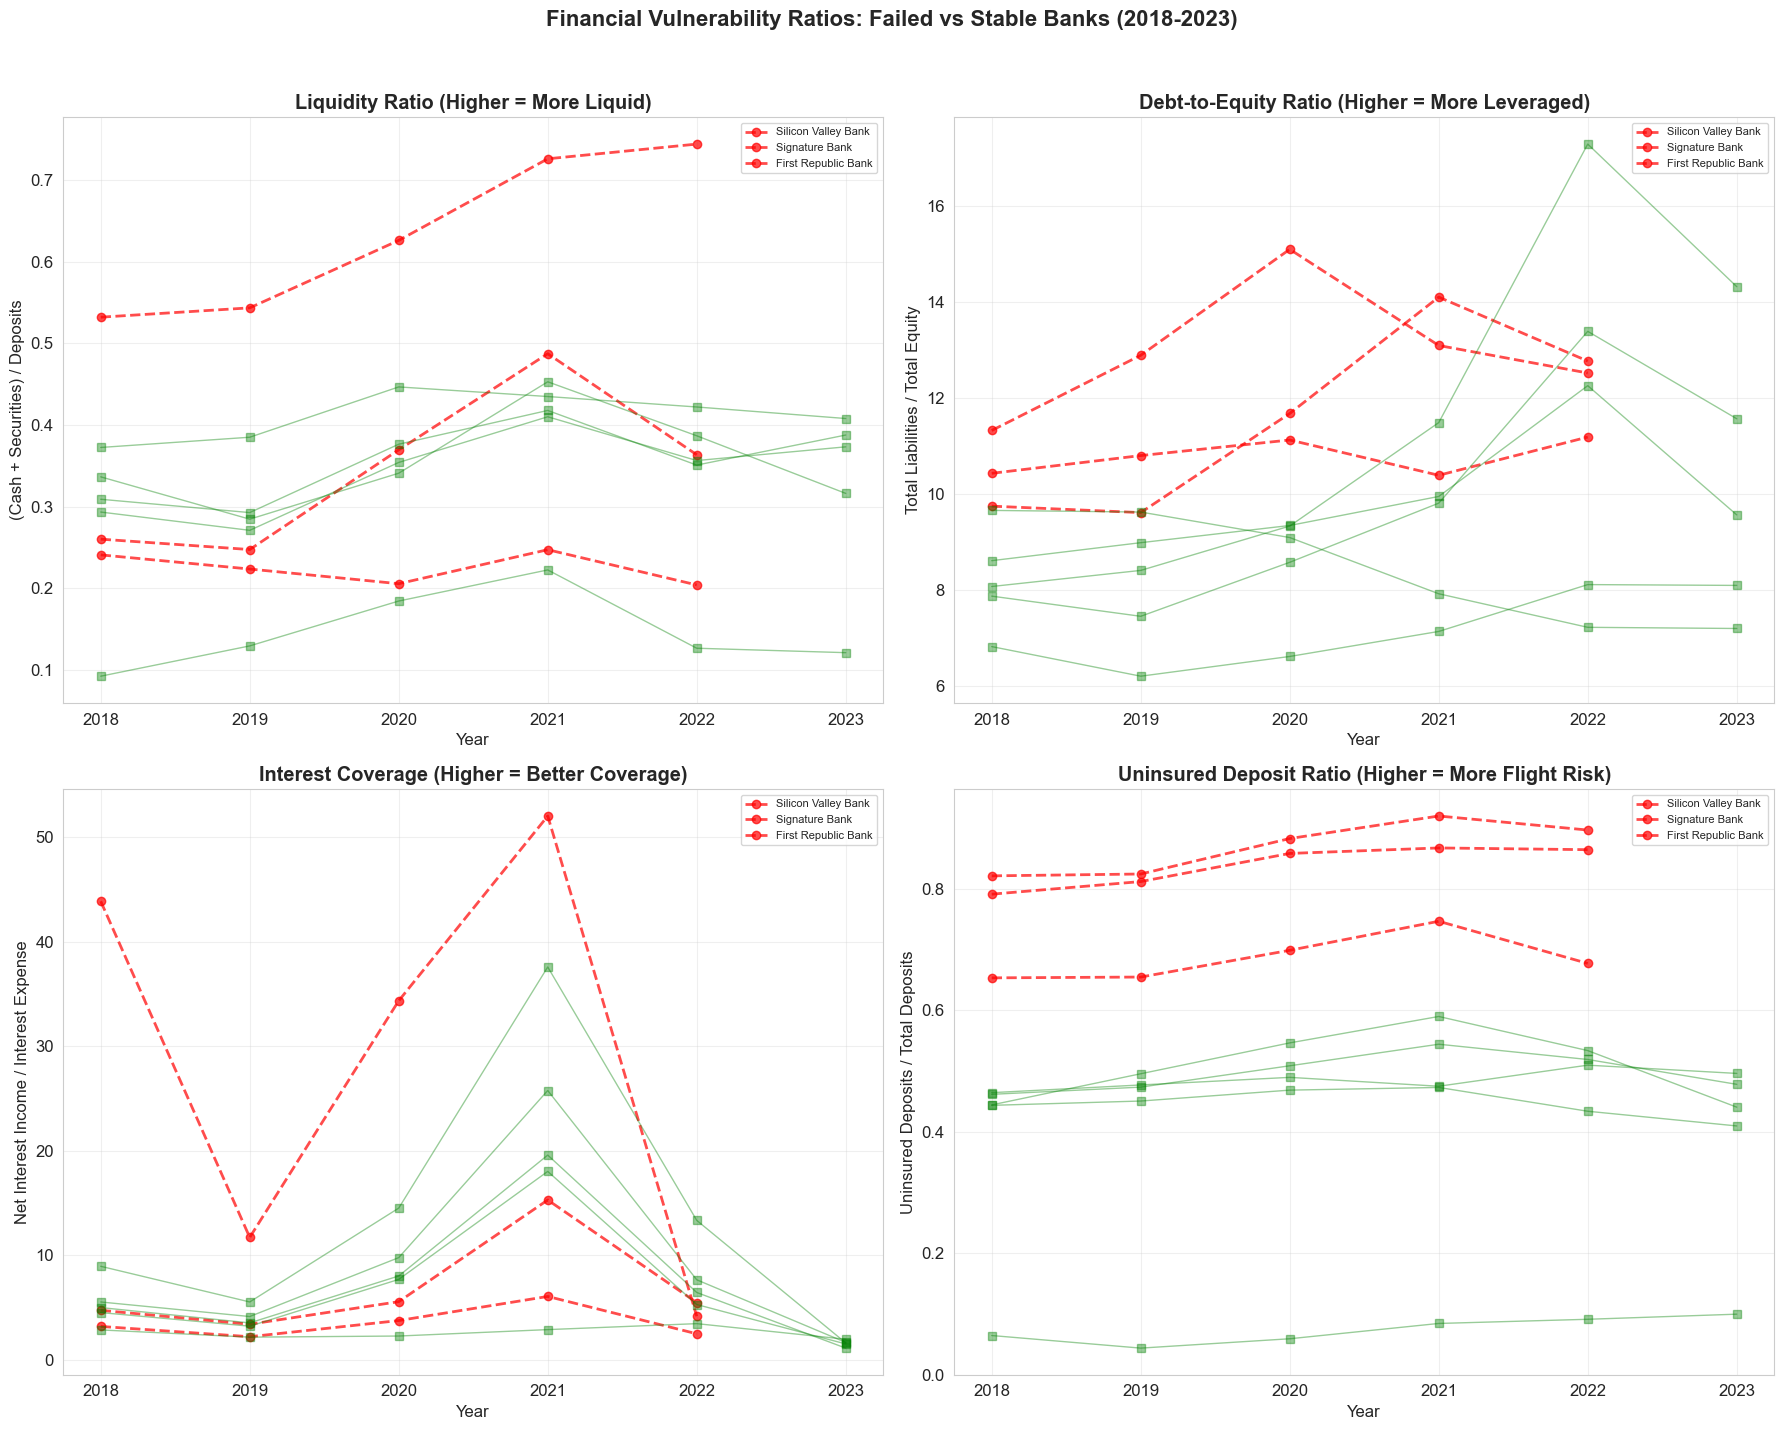

✅ Chart saved to outputs/ratio_trends.png


In [6]:
# =============================================================================
# CELL 6: Visualize Financial Ratio Trends Over Time
# =============================================================================

# Use annual data (Q4 of each year) for cleaner trend visualization
annual_df = financials_df[financials_df['quarter'] == 4].copy()

# If Q4 is missing, use latest available quarter per year
if annual_df.empty or len(annual_df) < 10:
    annual_df = financials_df.sort_values('report_date').groupby(['bank_name', 'year']).last().reset_index()

failed_banks = annual_df[annual_df['failed'] == True]
stable_banks = annual_df[annual_df['failed'] == False]

# --- Plot 1: Liquidity Ratio Trends ---
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Financial Vulnerability Ratios: Failed vs Stable Banks (2018-2023)', 
             fontsize=16, fontweight='bold', y=1.02)

# Liquidity Ratio
ax = axes[0, 0]
for name in failed_banks['bank_name'].unique():
    bank_data = failed_banks[failed_banks['bank_name'] == name]
    ax.plot(bank_data['year'], bank_data['liquidity_ratio'], 'r--o', alpha=0.7, label=name, linewidth=2)
for name in stable_banks['bank_name'].unique()[:5]:  # Top 5 stable for readability
    bank_data = stable_banks[stable_banks['bank_name'] == name]
    ax.plot(bank_data['year'], bank_data['liquidity_ratio'], 'g-s', alpha=0.4, linewidth=1)
ax.set_title('Liquidity Ratio (Higher = More Liquid)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('(Cash + Securities) / Deposits')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

# Debt-to-Equity
ax = axes[0, 1]
for name in failed_banks['bank_name'].unique():
    bank_data = failed_banks[failed_banks['bank_name'] == name]
    ax.plot(bank_data['year'], bank_data['debt_to_equity'], 'r--o', alpha=0.7, label=name, linewidth=2)
for name in stable_banks['bank_name'].unique()[:5]:
    bank_data = stable_banks[stable_banks['bank_name'] == name]
    ax.plot(bank_data['year'], bank_data['debt_to_equity'], 'g-s', alpha=0.4, linewidth=1)
ax.set_title('Debt-to-Equity Ratio (Higher = More Leveraged)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Liabilities / Total Equity')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

# Interest Coverage
ax = axes[1, 0]
for name in failed_banks['bank_name'].unique():
    bank_data = failed_banks[failed_banks['bank_name'] == name]
    ax.plot(bank_data['year'], bank_data['interest_coverage'], 'r--o', alpha=0.7, label=name, linewidth=2)
for name in stable_banks['bank_name'].unique()[:5]:
    bank_data = stable_banks[stable_banks['bank_name'] == name]
    ax.plot(bank_data['year'], bank_data['interest_coverage'], 'g-s', alpha=0.4, linewidth=1)
ax.set_title('Interest Coverage (Higher = Better Coverage)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Net Interest Income / Interest Expense')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

# Uninsured Deposit Ratio
ax = axes[1, 1]
for name in failed_banks['bank_name'].unique():
    bank_data = failed_banks[failed_banks['bank_name'] == name]
    ax.plot(bank_data['year'], bank_data['uninsured_deposit_ratio'], 'r--o', alpha=0.7, label=name, linewidth=2)
for name in stable_banks['bank_name'].unique()[:5]:
    bank_data = stable_banks[stable_banks['bank_name'] == name]
    ax.plot(bank_data['year'], bank_data['uninsured_deposit_ratio'], 'g-s', alpha=0.4, linewidth=1)
ax.set_title('Uninsured Deposit Ratio (Higher = More Flight Risk)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Uninsured Deposits / Total Deposits')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/ratio_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to outputs/ratio_trends.png")

---
## Cell 7 — Pull 10-K Risk Factors & MD&A Text from SEC EDGAR

This cell downloads the **Item 1A: Risk Factors** and **Item 7: Management's Discussion & Analysis** sections from annual 10-K filings for each target bank.

These text sections are the raw material for our **linguistic stress metric**.

**⚠️ Important:** 
- SEC EDGAR requires a `User-Agent` header with your name and email — update the `EDGAR_HEADERS` variable in Cell 2.
- We add polite delays between requests to respect SEC's 10 requests/second limit.

In [7]:
# =============================================================================
# CELL 7: Pull 10-K Risk Factors & MD&A Text from SEC EDGAR
# =============================================================================

def get_10k_filings_list(cik, filing_type="10-K"):
    """
    Get list of 10-K filing URLs for a given company CIK.
    Uses the EDGAR EFTS (full-text search) API.
    """
    # Clean CIK — remove leading zeros for URL, keep for search
    cik_clean = str(int(cik.lstrip('0')))
    
    url = f"https://efts.sec.gov/LATEST/search-index?q=%22{filing_type}%22&dateRange=custom&startdt=2018-01-01&enddt=2023-12-31&forms={filing_type}&from=0&size=10"
    
    # Alternative: use the submissions API (more reliable)
    submissions_url = f"https://data.sec.gov/submissions/CIK{cik}.json"
    
    try:
        response = requests.get(submissions_url, headers=EDGAR_HEADERS, timeout=30)
        response.raise_for_status()
        data = response.json()
        
        filings = []
        recent = data.get('filings', {}).get('recent', {})
        
        if recent:
            forms = recent.get('form', [])
            dates = recent.get('filingDate', [])
            accessions = recent.get('accessionNumber', [])
            primary_docs = recent.get('primaryDocument', [])
            
            for i, form in enumerate(forms):
                if form == filing_type and dates[i] >= '2017-01-01':
                    filings.append({
                        'form': form,
                        'date': dates[i],
                        'accession': accessions[i],
                        'primary_doc': primary_docs[i],
                        'url': f"https://www.sec.gov/Archives/edgar/data/{cik_clean}/{accessions[i].replace('-', '')}/{primary_docs[i]}"
                    })
        
        return filings
    
    except Exception as e:
        print(f"    ❌ Error fetching filing list: {e}")
        return []


def extract_section_from_10k(filing_url, section="risk_factors"):
    """
    Download a 10-K filing and extract the Risk Factors or MD&A section.
    
    Parameters:
        filing_url (str): URL to the 10-K filing document
        section (str): 'risk_factors' for Item 1A, 'mda' for Item 7
    
    Returns:
        str: Extracted text content of the section
    """
    try:
        response = requests.get(filing_url, headers=EDGAR_HEADERS, timeout=60)
        response.raise_for_status()
        
        soup = BeautifulSoup(response.content, 'html.parser')
        text = soup.get_text(separator=' ', strip=True)
        
        # Clean up whitespace
        text = re.sub(r'\s+', ' ', text)
        
        if section == "risk_factors":
            # Look for Item 1A section
            patterns = [
                r'(?i)item\s*1a\.?\s*risk\s*factors(.+?)item\s*1b',
                r'(?i)item\s*1a\.?\s*risk\s*factors(.+?)item\s*2',
                r'(?i)risk\s*factors(.+?)(?:item\s*1b|item\s*2|quantitative)',
            ]
        else:  # mda
            patterns = [
                r"(?i)item\s*7\.?\s*management'?s?\s*discussion(.+?)item\s*7a",
                r"(?i)item\s*7\.?\s*management'?s?\s*discussion(.+?)item\s*8",
                r"(?i)management'?s?\s*discussion\s*and\s*analysis(.+?)(?:item\s*7a|item\s*8)",
            ]
        
        for pattern in patterns:
            match = re.search(pattern, text)
            if match:
                extracted = match.group(1).strip()
                # Limit to reasonable length (some sections are very long)
                if len(extracted) > 500:
                    return extracted[:100000]  # Cap at 100K chars
        
        return ""
    
    except Exception as e:
        print(f"    ❌ Error extracting section: {e}")
        return ""


# --- Pull 10-K text for all target banks ---
print("📥 Fetching 10-K filings from SEC EDGAR...")
print("   (This may take 5-10 minutes — please be patient)")
print()

edgar_data = []

for bank_name, info in tqdm(TARGET_BANKS.items(), desc="Processing banks"):
    cik = info['cik']
    print(f"\n  📄 {bank_name} (CIK: {cik})")
    
    # Get list of 10-K filings
    filings = get_10k_filings_list(cik)
    print(f"     Found {len(filings)} 10-K filings")
    
    for filing in filings:
        filing_year = int(filing['date'][:4])
        
        # Extract Risk Factors
        print(f"     Extracting {filing['date']}...", end=" ")
        risk_text = extract_section_from_10k(filing['url'], section="risk_factors")
        mda_text = extract_section_from_10k(filing['url'], section="mda")
        
        edgar_data.append({
            'bank_name': bank_name,
            'cik': cik,
            'filing_date': filing['date'],
            'filing_year': filing_year,
            'accession': filing['accession'],
            'risk_factors_text': risk_text,
            'mda_text': mda_text,
            'risk_factors_length': len(risk_text),
            'mda_length': len(mda_text),
        })
        
        status = "✅" if (len(risk_text) > 0 or len(mda_text) > 0) else "⚠️ empty"
        print(f"RF: {len(risk_text):,} chars | MD&A: {len(mda_text):,} chars {status}")
        
        # Respectful rate limiting for SEC
        time.sleep(0.5)

edgar_df = pd.DataFrame(edgar_data)

# Save raw text data
edgar_df.to_csv('data/edgar_10k_text_raw.csv', index=False)

print(f"\n✅ EDGAR data fetched successfully!")
print(f"   Total filings processed: {len(edgar_df)}")
print(f"   Filings with Risk Factors: {(edgar_df['risk_factors_length'] > 0).sum()}")
print(f"   Filings with MD&A text:    {(edgar_df['mda_length'] > 0).sum()}")
print(f"   Saved to: data/edgar_10k_text_raw.csv")

📥 Fetching 10-K filings from SEC EDGAR...
   (This may take 5-10 minutes — please be patient)



Processing banks:   0%|          | 0/30 [00:00<?, ?it/s]


  📄 Silicon Valley Bank (CIK: 0000719739)
     Found 7 10-K filings
     Extracting 2023-02-24... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2022-03-01... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2021-03-01... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2020-02-28... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2019-02-28... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2018-02-28... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2017-02-28... RF: 0 chars | MD&A: 0 chars ⚠️ empty


Processing banks:   3%|▎         | 1/30 [00:30<14:37, 30.27s/it]


  📄 Signature Bank (CIK: 0001288854)


...

     Found 0 10-K filings

  📄 South State Corporation (CIK: 0000764478)
     Found 10 10-K filings
     Extracting 2026-03-18... RF: 532 chars | MD&A: 0 chars ✅
     Extracting 2025-03-19... RF: 518 chars | MD&A: 0 chars ✅
     Extracting 2024-03-15... RF: 518 chars | MD&A: 0 chars ✅
     Extracting 2023-03-17... RF: 516 chars | MD&A: 0 chars ✅
     Extracting 2022-03-18... RF: 516 chars | MD&A: 0 chars ✅
     Extracting 2021-03-19... RF: 516 chars | MD&A: 0 chars ✅
     Extracting 2020-03-23... RF: 534 chars | MD&A: 0 chars ✅
     Extracting 2019-03-28... RF: 512 chars | MD&A: 0 chars ✅
     Extracting 2018-04-02... RF: 512 chars | MD&A: 0 chars ✅
     Extracting 2017-03-24... RF: 512 chars | MD&A: 0 chars ✅


Processing banks:  97%|█████████▋| 29/30 [09:17<00:19, 19.27s/it]


  📄 Pinnacle Financial Partners (CIK: 0001115055)
     Found 9 10-K filings
     Extracting 2025-02-25... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2024-02-26... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2023-02-28... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2022-02-28... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2021-02-26... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2020-02-25... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2019-02-28... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2018-02-28... RF: 0 chars | MD&A: 0 chars ⚠️ empty
     Extracting 2017-02-27... RF: 0 chars | MD&A: 0 chars ⚠️ empty


Processing banks: 100%|██████████| 30/30 [09:40<00:00, 19.36s/it]


✅ EDGAR data fetched successfully!
   Total filings processed: 205
   Filings with Risk Factors: 43
   Filings with MD&A text:    41
   Saved to: data/edgar_10k_text_raw.csv


---
## Cell 8 — NLP Textual Stress Scoring

This cell builds the **linguistic stress metric** from 10-K Risk Factors and MD&A sections.

We measure three dimensions of textual stress:

1. **Hedging Language Density** — Frequency of uncertainty words ("may", "could", "uncertain", "possible", "expect", "anticipate") normalized by document length.

2. **Sentiment Score** — Using VADER sentiment analysis on the Risk Factors section. More negative = more stressed.

3. **Risk Section Growth** — Year-over-year change in the length of the Risk Factors section. Growing risk disclosures signal increasing concern.

These three dimensions are combined into a single **Textual Stress Score**.

In [8]:
# =============================================================================
# CELL 8: NLP Textual Stress Scoring
# =============================================================================

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# --- Define hedging/uncertainty vocabulary ---
HEDGING_TERMS = [
    'may', 'might', 'could', 'would', 'should', 'possibly', 'potentially',
    'uncertain', 'uncertainty', 'risk', 'risks', 'volatile', 'volatility',
    'adverse', 'adversely', 'material', 'materially', 'significant',
    'significantly', 'expect', 'expected', 'anticipate', 'anticipated',
    'believe', 'estimate', 'estimated', 'approximately', 'likely',
    'unlikely', 'fluctuate', 'fluctuation', 'decline', 'decrease',
    'impair', 'impairment', 'loss', 'losses', 'default', 'defaults',
    'downturn', 'recession', 'stress', 'stressed', 'concern', 'concerned',
    'contingent', 'contingency', 'litigation', 'regulatory', 'compliance',
    'deteriorate', 'deterioration', 'weakness', 'unable', 'failure',
    'exposure', 'concentrated', 'concentration', 'illiquid', 'illiquidity',
    'unrealized', 'write-down', 'writedown', 'charge-off', 'chargeoff',
]

# Severe distress terms (weighted higher)
SEVERE_TERMS = [
    'insolvency', 'insolvent', 'bankruptcy', 'liquidation', 'receivership',
    'going concern', 'capital deficiency', 'undercapitalized', 'critically',
    'systemic', 'contagion', 'bank run', 'deposit flight', 'fire sale',
]


def compute_textual_stress(text, text_type="risk_factors"):
    """
    Compute textual stress metrics from a 10-K section.
    
    Returns dict with:
        - hedging_density: hedging terms per 1000 words
        - severe_density: severe distress terms per 1000 words
        - sentiment_compound: VADER compound sentiment (-1 to +1)
        - sentiment_negative: VADER negative sentiment proportion
        - word_count: total words in section
    """
    if not text or len(text.strip()) < 100:
        return {
            'hedging_density': np.nan,
            'severe_density': np.nan,
            'sentiment_compound': np.nan,
            'sentiment_negative': np.nan,
            'word_count': 0
        }
    
    # Tokenize
    words = text.lower().split()
    word_count = len(words)
    
    if word_count == 0:
        return {
            'hedging_density': np.nan,
            'severe_density': np.nan,
            'sentiment_compound': np.nan,
            'sentiment_negative': np.nan,
            'word_count': 0
        }
    
    # Count hedging terms
    hedging_count = sum(1 for w in words if w.strip('.,;:()') in HEDGING_TERMS)
    hedging_density = (hedging_count / word_count) * 1000  # per 1000 words
    
    # Count severe distress terms (check bigrams too)
    text_lower = text.lower()
    severe_count = sum(text_lower.count(term) for term in SEVERE_TERMS)
    severe_density = (severe_count / word_count) * 1000
    
    # VADER sentiment (on chunks to handle long text)
    # VADER works best on sentence-level, so we chunk and average
    chunk_size = 5000
    chunks = [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]
    
    sentiments = [sia.polarity_scores(chunk) for chunk in chunks[:20]]  # Cap at 20 chunks
    avg_compound = np.mean([s['compound'] for s in sentiments])
    avg_negative = np.mean([s['neg'] for s in sentiments])
    
    return {
        'hedging_density': hedging_density,
        'severe_density': severe_density,
        'sentiment_compound': avg_compound,
        'sentiment_negative': avg_negative,
        'word_count': word_count
    }


# --- Apply NLP scoring to all filings ---
print("🔤 Computing textual stress scores from 10-K filings...")
print()

# Score Risk Factors
rf_scores = edgar_df['risk_factors_text'].apply(
    lambda x: pd.Series(compute_textual_stress(x, "risk_factors"))
)
rf_scores.columns = ['rf_' + col for col in rf_scores.columns]

# Score MD&A
mda_scores = edgar_df['mda_text'].apply(
    lambda x: pd.Series(compute_textual_stress(x, "mda"))
)
mda_scores.columns = ['mda_' + col for col in mda_scores.columns]

# Combine with edgar_df
edgar_scored = pd.concat([edgar_df[['bank_name', 'filing_date', 'filing_year', 
                                      'risk_factors_length', 'mda_length']], 
                           rf_scores, mda_scores], axis=1)

# --- Compute year-over-year Risk Factors growth ---
edgar_scored = edgar_scored.sort_values(['bank_name', 'filing_year'])
edgar_scored['rf_length_yoy_change'] = edgar_scored.groupby('bank_name')['risk_factors_length'].pct_change()
edgar_scored['mda_length_yoy_change'] = edgar_scored.groupby('bank_name')['mda_length'].pct_change()

# Save scored data
edgar_scored.to_csv('data/edgar_textual_stress_scores.csv', index=False)

print("📊 Textual Stress Score Summary:")
print("=" * 60)
print(edgar_scored[['rf_hedging_density', 'rf_severe_density', 
                     'rf_sentiment_compound', 'rf_sentiment_negative',
                     'rf_word_count', 'rf_length_yoy_change']].describe().round(4))
print()
print("✅ Textual stress scores computed and saved to data/edgar_textual_stress_scores.csv")

🔤 Computing textual stress scores from 10-K filings...

📊 Textual Stress Score Summary:
       rf_hedging_density  rf_severe_density  rf_sentiment_compound  \
count             43.0000            43.0000                43.0000   
mean              39.7490             0.3974                 0.3889   
std               17.5396             0.6631                 0.4999   
min               10.1215             0.0000                -0.6027   
25%               24.9795             0.0000                 0.1727   
50%               33.7079             0.1976                 0.5319   
75%               57.7812             0.3297                 0.8323   
max               66.0998             2.5271                 0.9954   

       rf_sentiment_negative  rf_word_count  rf_length_yoy_change  
count                43.0000       205.0000               41.0000  
mean                  0.0648      1467.8488                   inf  
std                   0.0324      3898.1273                   NaN  


---
## Cell 9 — Stock Price Drawdown Analysis

Pull stock price data from Yahoo Finance to compute maximum drawdowns for each bank. This supplements our ground truth — banks with >60% drawdown from peak are flagged as experiencing significant distress, even if they didn't technically fail.

In [9]:
# =============================================================================
# CELL 9: Stock Price Drawdown Analysis
# =============================================================================

def compute_max_drawdown(ticker, start="2018-01-01", end="2023-12-31"):
    """
    Compute maximum drawdown for a stock over a given period.
    
    Returns:
        dict with max_drawdown, drawdown_date, peak_price, trough_price
    """
    try:
        stock = yf.Ticker(ticker)
        hist = stock.history(start=start, end=end)
        
        if hist.empty or len(hist) < 10:
            return {'max_drawdown': np.nan, 'peak_price': np.nan, 
                    'trough_price': np.nan, 'peak_date': None, 'trough_date': None}
        
        # Compute rolling maximum
        rolling_max = hist['Close'].expanding(min_periods=1).max()
        drawdown = (hist['Close'] - rolling_max) / rolling_max
        
        max_dd = drawdown.min()
        trough_idx = drawdown.idxmin()
        peak_idx = hist['Close'][:trough_idx].idxmax()
        
        return {
            'max_drawdown': max_dd,
            'peak_price': hist['Close'][peak_idx],
            'trough_price': hist['Close'][trough_idx],
            'peak_date': peak_idx.strftime('%Y-%m-%d') if hasattr(peak_idx, 'strftime') else str(peak_idx),
            'trough_date': trough_idx.strftime('%Y-%m-%d') if hasattr(trough_idx, 'strftime') else str(trough_idx),
        }
    
    except Exception as e:
        print(f"  ❌ Error for {ticker}: {e}")
        return {'max_drawdown': np.nan, 'peak_price': np.nan,
                'trough_price': np.nan, 'peak_date': None, 'trough_date': None}


# --- Pull drawdown data for all banks ---
print("📈 Computing stock price drawdowns...")
print()

drawdown_data = []
for bank_name, info in tqdm(TARGET_BANKS.items(), desc="Analyzing drawdowns"):
    ticker = info['ticker']
    dd = compute_max_drawdown(ticker)
    dd['bank_name'] = bank_name
    dd['ticker'] = ticker
    dd['failed'] = info['failed']
    drawdown_data.append(dd)
    time.sleep(0.3)

drawdown_df = pd.DataFrame(drawdown_data)

# Flag severe drawdowns (>60%)
drawdown_df['severe_drawdown'] = drawdown_df['max_drawdown'] < -0.60

# Create combined distress label
# True if: failed OR had >60% drawdown
drawdown_df['distressed'] = drawdown_df['failed'] | drawdown_df['severe_drawdown']

# Display results
print("\n📊 Stock Price Drawdown Summary:")
print("=" * 80)
print(drawdown_df[['bank_name', 'ticker', 'max_drawdown', 'peak_date', 'trough_date', 
                     'failed', 'severe_drawdown', 'distressed']]
      .sort_values('max_drawdown')
      .to_string(index=False, float_format='{:.2%}'.format))

drawdown_df.to_csv('data/stock_drawdowns.csv', index=False)
print("\n✅ Drawdown data saved to data/stock_drawdowns.csv")

📈 Computing stock price drawdowns...



Analyzing drawdowns: 100%|██████████| 30/30 [00:16<00:00,  1.86it/s]


📊 Stock Price Drawdown Summary:
                      bank_name ticker  max_drawdown  peak_date trough_date  failed  severe_drawdown  distressed
Western Alliance Bancorporation    WAL       -84.79% 2021-11-03  2023-05-04   False             True        True
             Wintrust Financial   WTFC       -74.50% 2018-05-21  2020-03-18   False             True        True
           Zions Bancorporation   ZION       -72.23% 2022-02-15  2023-05-04   False             True        True
              Webster Financial    WBS       -71.99% 2018-07-23  2020-03-23   False             True        True
       Citizens Financial Group    CFG       -65.60% 2018-01-23  2020-03-18   False             True        True
                        KeyCorp    KEY       -65.23% 2022-01-14  2023-05-04   False             True        True
                  First Horizon    FHN       -64.25% 2018-01-11  2020-03-23   False             True        True
            Fifth Third Bancorp   FITB       -64.06% 2018-05-16

---
## Cell 10 — Merge All Data Sources & Build Feature Matrix

Combine:
1. FDIC quarterly financials (ratios) — annualized to match filing years
2. EDGAR textual stress scores — one per filing year
3. Stock drawdown labels — distress ground truth

This produces the final **feature matrix** used for fragility scoring.

In [10]:
# =============================================================================
# CELL 10: Merge All Data Sources & Build Feature Matrix
# =============================================================================

# --- Step 1: Annualize financial data (use Q4 or latest quarter per year) ---
annual_financials = (
    financials_df
    .sort_values(['bank_name', 'report_date'])
    .groupby(['bank_name', 'year'])
    .last()
    .reset_index()
)

print(f"📊 Annual financial records: {len(annual_financials)}")

# --- Step 2: Merge with textual stress scores ---
# Match on bank_name and year
merged = annual_financials.merge(
    edgar_scored,
    left_on=['bank_name', 'year'],
    right_on=['bank_name', 'filing_year'],
    how='left',
    suffixes=('', '_edgar')
)

print(f"📊 After merging with EDGAR text: {len(merged)}")

# --- Step 3: Merge with drawdown / distress labels ---
merged = merged.merge(
    drawdown_df[['bank_name', 'max_drawdown', 'severe_drawdown', 'distressed']],
    on='bank_name',
    how='left'
)

print(f"📊 After merging with drawdown labels: {len(merged)}")

# --- Step 4: Compute year-over-year changes for financial ratios ---
merged = merged.sort_values(['bank_name', 'year'])

ratio_cols_for_yoy = ['liquidity_ratio', 'debt_to_equity', 'interest_coverage', 
                       'loan_to_deposit', 'uninsured_deposit_ratio']

for col in ratio_cols_for_yoy:
    merged[f'{col}_yoy'] = merged.groupby('bank_name')[col].pct_change()

# --- Step 5: Define final feature columns ---
FEATURE_COLS = [
    # Financial ratios
    'liquidity_ratio', 'debt_to_equity', 'interest_coverage',
    'loan_to_deposit', 'uninsured_deposit_ratio',
    'npa_ratio', 'core_deposit_ratio', 'reserve_ratio',
    'ROA', 'ROE',
    
    # Year-over-year changes
    'liquidity_ratio_yoy', 'debt_to_equity_yoy', 'interest_coverage_yoy',
    'loan_to_deposit_yoy', 'uninsured_deposit_ratio_yoy',
    
    # Textual stress metrics
    'rf_hedging_density', 'rf_severe_density',
    'rf_sentiment_compound', 'rf_sentiment_negative',
    'rf_word_count', 'rf_length_yoy_change',
    'mda_hedging_density', 'mda_sentiment_compound',
]

# Check which features are available
available_features = [col for col in FEATURE_COLS if col in merged.columns]
missing_features = [col for col in FEATURE_COLS if col not in merged.columns]

print(f"\n✅ Feature matrix built!")
print(f"   Available features: {len(available_features)}")
if missing_features:
    print(f"   Missing features:   {missing_features}")
print(f"   Total observations: {len(merged)}")
print(f"   Banks:              {merged['bank_name'].nunique()}")
print(f"   Years:              {sorted(merged['year'].unique())}")

# Save merged dataset
merged.to_csv('data/merged_feature_matrix.csv', index=False)
print(f"\n   Saved to: data/merged_feature_matrix.csv")

📊 Annual financial records: 112
📊 After merging with EDGAR text: 112
📊 After merging with drawdown labels: 112

✅ Feature matrix built!
   Available features: 23
   Total observations: 112
   Banks:              19
   Years:              [2018, 2019, 2020, 2021, 2022, 2023]

   Saved to: data/merged_feature_matrix.csv


---
## Cell 11 — Construct the Weighted Fragility Index

The Fragility Index combines all features into a single score using a **weighted scoring function**:

**Fragility Score = w₁·Liquidity_Risk + w₂·Leverage_Risk + w₃·Coverage_Risk + w₄·Deposit_Risk + w₅·Textual_Stress**

Each component is normalized to [0, 1] using percentile ranking, where **higher = more fragile**.

Note: Some ratios are inverted (e.g., liquidity ratio where higher = safer becomes "liquidity risk" where higher = riskier).

In [11]:
# =============================================================================
# CELL 11: Construct the Weighted Fragility Index
# =============================================================================

def build_fragility_index(df, weights=None):
    """
    Construct a composite fragility index from financial and textual features.
    
    Each component is percentile-ranked (0-1 scale), where 1 = most fragile.
    Ratios where higher = safer are inverted.
    
    Parameters:
        df: DataFrame with computed ratios and textual scores
        weights: dict of component weights (must sum to 1.0)
    
    Returns:
        DataFrame with fragility scores added
    """
    result = df.copy()
    
    if weights is None:
        weights = {
            'liquidity_risk': 0.25,      # Liquidity vulnerability
            'leverage_risk': 0.20,        # Leverage/capital risk
            'coverage_risk': 0.15,        # Interest coverage weakness
            'deposit_risk': 0.20,         # Deposit concentration/flight risk
            'textual_stress': 0.20,       # Linguistic stress signal
        }
    
    # --- Component 1: Liquidity Risk (invert — lower liquidity = higher risk) ---
    result['liquidity_risk_raw'] = 1 - result['liquidity_ratio'].clip(0, 2) / 2
    result['liquidity_risk'] = result['liquidity_risk_raw'].rank(pct=True)
    
    # --- Component 2: Leverage Risk (higher D/E = higher risk) ---
    result['leverage_risk_raw'] = result['debt_to_equity'].clip(0, 50)
    result['leverage_risk'] = result['leverage_risk_raw'].rank(pct=True)
    
    # --- Component 3: Coverage Risk (invert — lower coverage = higher risk) ---
    result['coverage_risk_raw'] = 1 / (1 + result['interest_coverage'].clip(0, 20))
    result['coverage_risk'] = result['coverage_risk_raw'].rank(pct=True)
    
    # --- Component 4: Deposit Risk (composite of uninsured ratio + loan/deposit) ---
    result['deposit_risk_raw'] = (
        0.6 * result['uninsured_deposit_ratio'].fillna(0).rank(pct=True) +
        0.4 * result['loan_to_deposit'].fillna(0).rank(pct=True)
    )
    result['deposit_risk'] = result['deposit_risk_raw'].rank(pct=True)
    
    # --- Component 5: Textual Stress (composite of NLP features) ---
    text_features = ['rf_hedging_density', 'rf_sentiment_negative', 'rf_length_yoy_change']
    available_text = [f for f in text_features if f in result.columns and result[f].notna().any()]
    
    if available_text:
        text_ranks = pd.DataFrame()
        for feat in available_text:
            text_ranks[feat] = result[feat].rank(pct=True)
        result['textual_stress'] = text_ranks.mean(axis=1).fillna(0.5)
    else:
        result['textual_stress'] = 0.5  # Neutral if no text data available
        print("  ⚠️  No textual stress data available — using neutral score (0.5)")
    
    # --- Ensure no NaN in components before scoring ---
    result['textual_stress'] = result['textual_stress'].fillna(0.5)
    result['liquidity_risk'] = result['liquidity_risk'].fillna(0.5)
    result['leverage_risk'] = result['leverage_risk'].fillna(0.5)
    result['coverage_risk'] = result['coverage_risk'].fillna(0.5)
    result['deposit_risk'] = result['deposit_risk'].fillna(0.5)
    
    # --- Compute Weighted Fragility Score ---
    result['fragility_score'] = (
        weights['liquidity_risk'] * result['liquidity_risk'] +
        weights['leverage_risk'] * result['leverage_risk'] +
        weights['coverage_risk'] * result['coverage_risk'] +
        weights['deposit_risk'] * result['deposit_risk'] +
        weights['textual_stress'] * result['textual_stress']
    )
    
    # Percentile rank the final score
    result['fragility_percentile'] = result['fragility_score'].rank(pct=True) * 100
    
    # Risk tier classification
    result['risk_tier'] = pd.cut(
        result['fragility_percentile'],
        bins=[0, 25, 50, 75, 90, 100],
        labels=['Low', 'Moderate', 'Elevated', 'High', 'Critical'],
        include_lowest=True
    )
    
    return result


# Build fragility index
merged = build_fragility_index(merged)

# --- Display latest year fragility rankings ---
latest_year = merged['year'].max()
latest = merged[merged['year'] == latest_year].sort_values('fragility_score', ascending=False)

print(f"🏦 Fragility Index Rankings — {latest_year}")
print("=" * 90)
print(f"{'Bank':<35} {'Fragility':>10} {'Percentile':>11} {'Tier':<10} {'Failed?':<8}")
print("-" * 90)
for _, row in latest.iterrows():
    print(f"{row['bank_name']:<35} {row['fragility_score']:>10.4f} {row['fragility_percentile']:>10.1f}% {str(row['risk_tier']):<10} {'⚠️ YES' if row['failed'] else '✅ No':<8}")

# Save with fragility scores
merged.to_csv('data/fragility_scored.csv', index=False)
print(f"\n✅ Fragility index computed and saved to data/fragility_scored.csv")

🏦 Fragility Index Rankings — 2023
Bank                                 Fragility  Percentile Tier       Failed? 
------------------------------------------------------------------------------------------
First Horizon                           0.7330       99.1% Critical   ✅ No    
KeyCorp                                 0.6857       92.9% Critical   ✅ No    
Zions Bancorporation                    0.6567       89.3% High       ✅ No    
First Republic Bank                     0.6554       88.4% High       ⚠️ YES  
M&T Bank                                0.6250       82.1% High       ✅ No    
Prosperity Bancshares                   0.6112       81.2% High       ✅ No    
Wintrust Financial                      0.5875       75.4% High       ✅ No    
PacWest Bancorp                         0.5875       75.4% High       ✅ No    
Huntington Bancshares                   0.5496       61.6% Elevated   ✅ No    
Synovus Financial                       0.5326       55.4% Elevated   ✅ No    
Region

---
## Cell 12 — Visualize Fragility Scores

Generate comprehensive visualizations of the fragility index:
1. Fragility score heatmap across banks and years
2. Fragility component breakdown for top-risk banks
3. Time-series of fragility scores with distress events marked

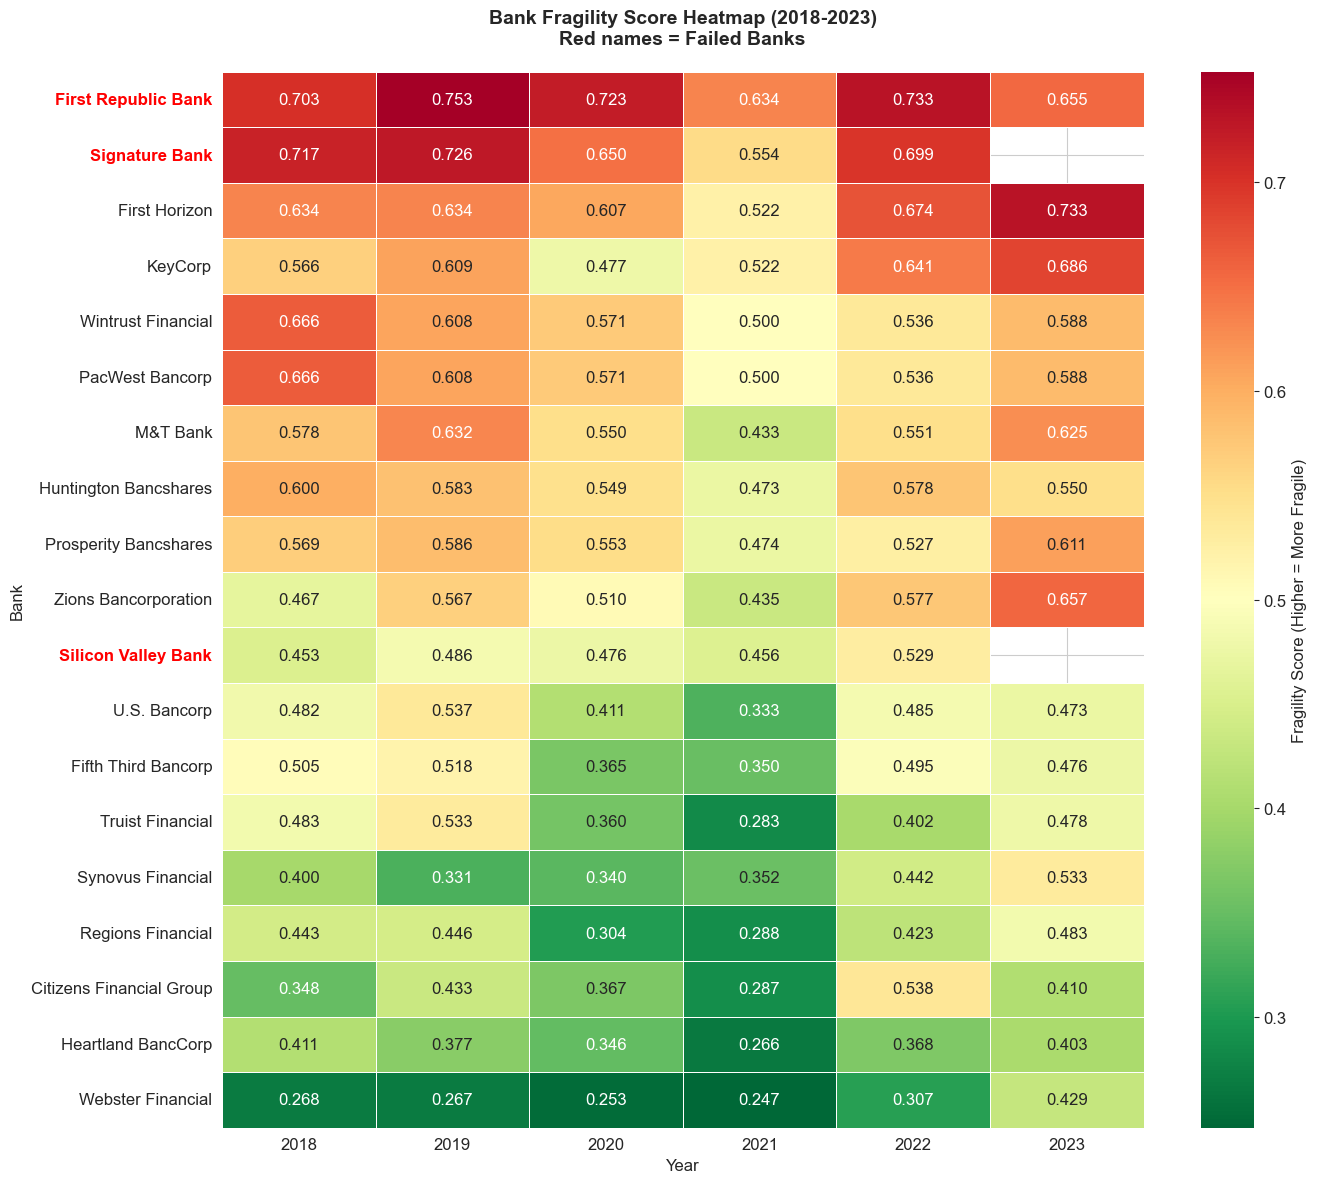

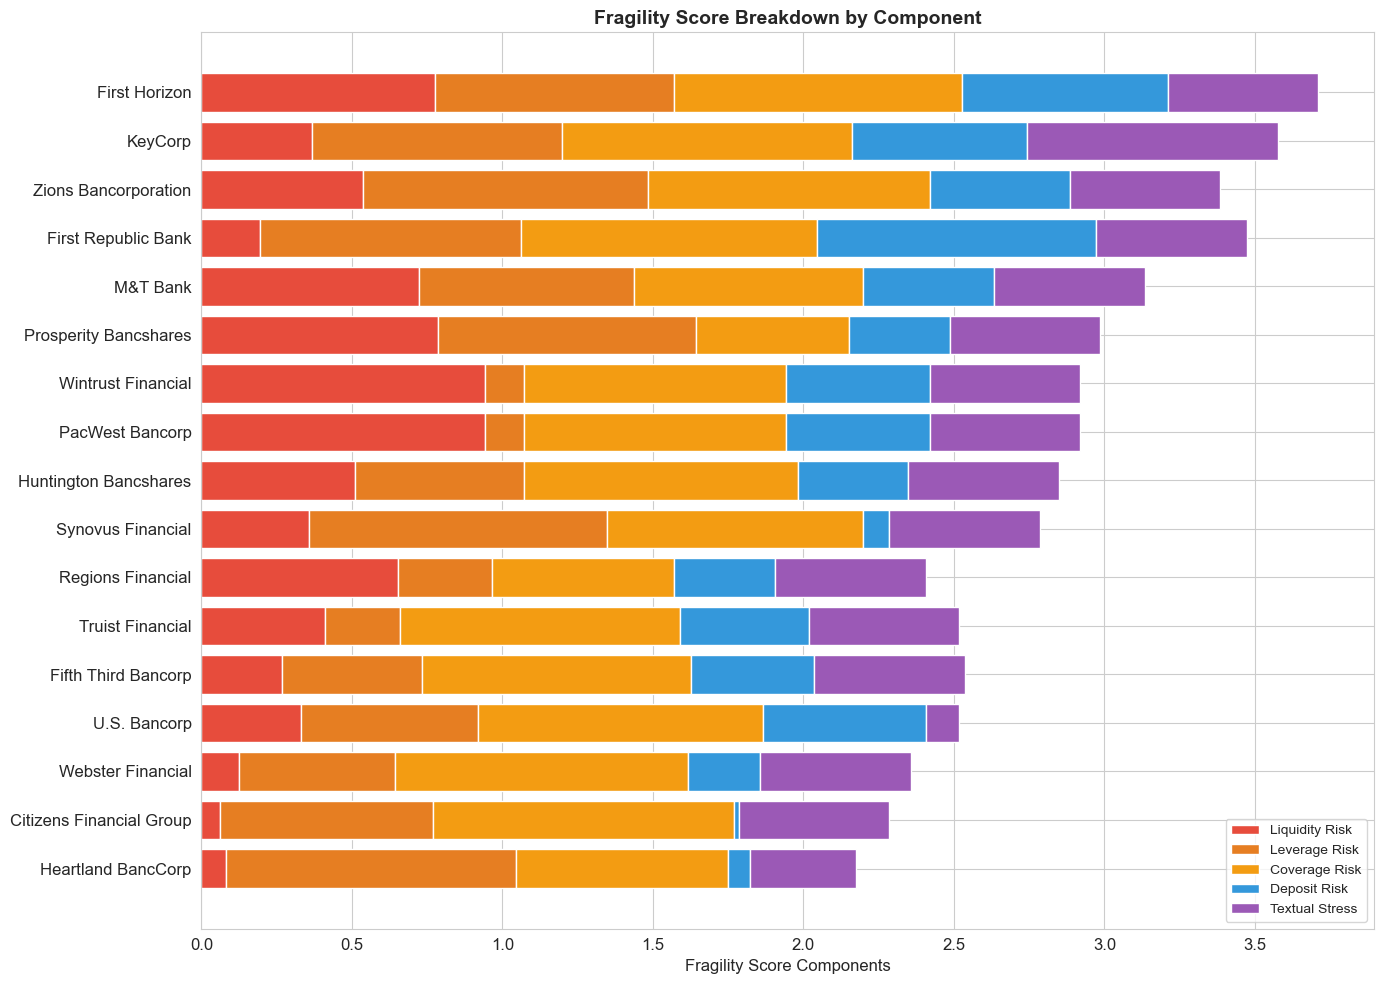

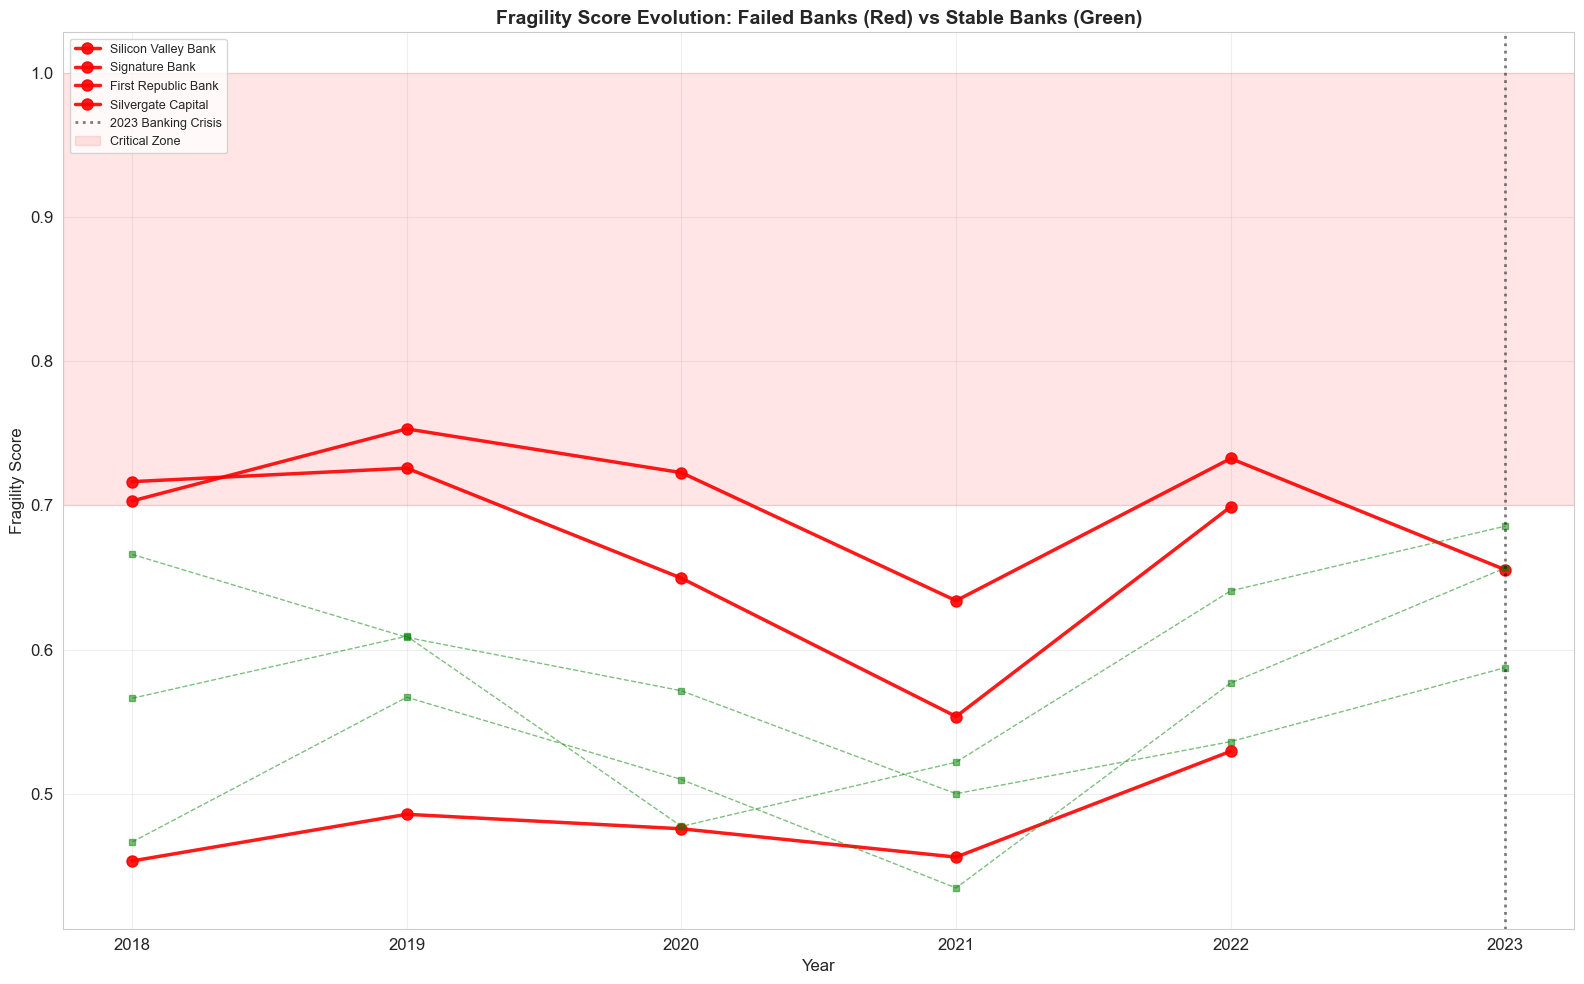

✅ All visualizations saved to outputs/ directory


In [12]:
# =============================================================================
# CELL 12: Visualize Fragility Scores
# =============================================================================

# --- Plot 1: Fragility Score Heatmap ---
pivot = merged.pivot_table(
    values='fragility_score', 
    index='bank_name', 
    columns='year',
    aggfunc='mean'
)

# Sort by average fragility
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Fragility Score (Higher = More Fragile)'},
    ax=ax
)

# Highlight failed banks
for i, bank in enumerate(pivot.index):
    if bank in [b for b, info in TARGET_BANKS.items() if info['failed']]:
        ax.get_yticklabels()[i].set_color('red')
        ax.get_yticklabels()[i].set_fontweight('bold')

ax.set_title('Bank Fragility Score Heatmap (2018-2023)\nRed names = Failed Banks', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Bank', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/fragility_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: Fragility Component Breakdown (Latest Year) ---
latest = merged[merged['year'] == merged['year'].max()].sort_values('fragility_score', ascending=True)
components = ['liquidity_risk', 'leverage_risk', 'coverage_risk', 'deposit_risk', 'textual_stress']

fig, ax = plt.subplots(figsize=(14, 10))
colors = ['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#9b59b6']
left = np.zeros(len(latest))

for i, comp in enumerate(components):
    values = latest[comp].values
    bars = ax.barh(latest['bank_name'], values, left=left, color=colors[i], label=comp.replace('_', ' ').title())
    left += values

ax.set_xlabel('Fragility Score Components', fontsize=12)
ax.set_title('Fragility Score Breakdown by Component', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/fragility_components.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 3: Fragility Score Time Series ---
fig, ax = plt.subplots(figsize=(16, 10))

failed_names = [b for b, info in TARGET_BANKS.items() if info['failed']]
stable_names = [b for b, info in TARGET_BANKS.items() if not info['failed']]

for name in failed_names:
    bank_data = merged[merged['bank_name'] == name].sort_values('year')
    ax.plot(bank_data['year'], bank_data['fragility_score'], 'r-o', 
            linewidth=2.5, markersize=8, label=name, alpha=0.9)

for name in stable_names[:5]:  # Top 5 stable for readability
    bank_data = merged[merged['bank_name'] == name].sort_values('year')
    ax.plot(bank_data['year'], bank_data['fragility_score'], '--s', 
            linewidth=1, markersize=5, alpha=0.5, color='green')

# Mark the 2023 crisis
ax.axvline(x=2023, color='black', linestyle=':', linewidth=2, alpha=0.5, label='2023 Banking Crisis')
ax.axhspan(0.7, 1.0, alpha=0.1, color='red', label='Critical Zone')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Fragility Score', fontsize=12)
ax.set_title('Fragility Score Evolution: Failed Banks (Red) vs Stable Banks (Green)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/fragility_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ All visualizations saved to outputs/ directory")

---
## Cell 13 — Machine Learning Model: Distress Classification

Train a classification model to predict bank distress using the feature matrix.

We use multiple approaches:
1. **Logistic Regression** — interpretable baseline
2. **Gradient Boosting** — stronger predictive model
3. **Random Forest** — ensemble approach

Evaluation metrics:
- ROC-AUC
- Precision @ Top 20% most fragile
- Feature importance analysis

📊 Training set: 64 observations (39 distressed)
📊 Test set:     36 observations (20 distressed)
📊 Features:     23

Model 1: Logistic Regression
  ROC-AUC: 0.6875
  Accuracy: 0.6667

Model 2: Gradient Boosting Classifier
  ROC-AUC: 0.8781
  Accuracy: 0.8333

Model 3: Random Forest Classifier
  ROC-AUC: 0.8562
  Accuracy: 0.7222

Feature Importance (Gradient Boosting)
  npa_ratio                           0.3628 ████████████████████████████████████
  uninsured_deposit_ratio             0.3136 ███████████████████████████████
  mda_hedging_density                 0.1509 ███████████████
  liquidity_ratio                     0.0691 ██████
  ROE                                 0.0409 ████
  debt_to_equity                      0.0233 ██
  debt_to_equity_yoy                  0.0118 █
  uninsured_deposit_ratio_yoy         0.0105 █
  core_deposit_ratio                  0.0070 
  loan_to_deposit_yoy                 0.0065 
  interest_coverage_yoy               0.0020 
  ROA                       

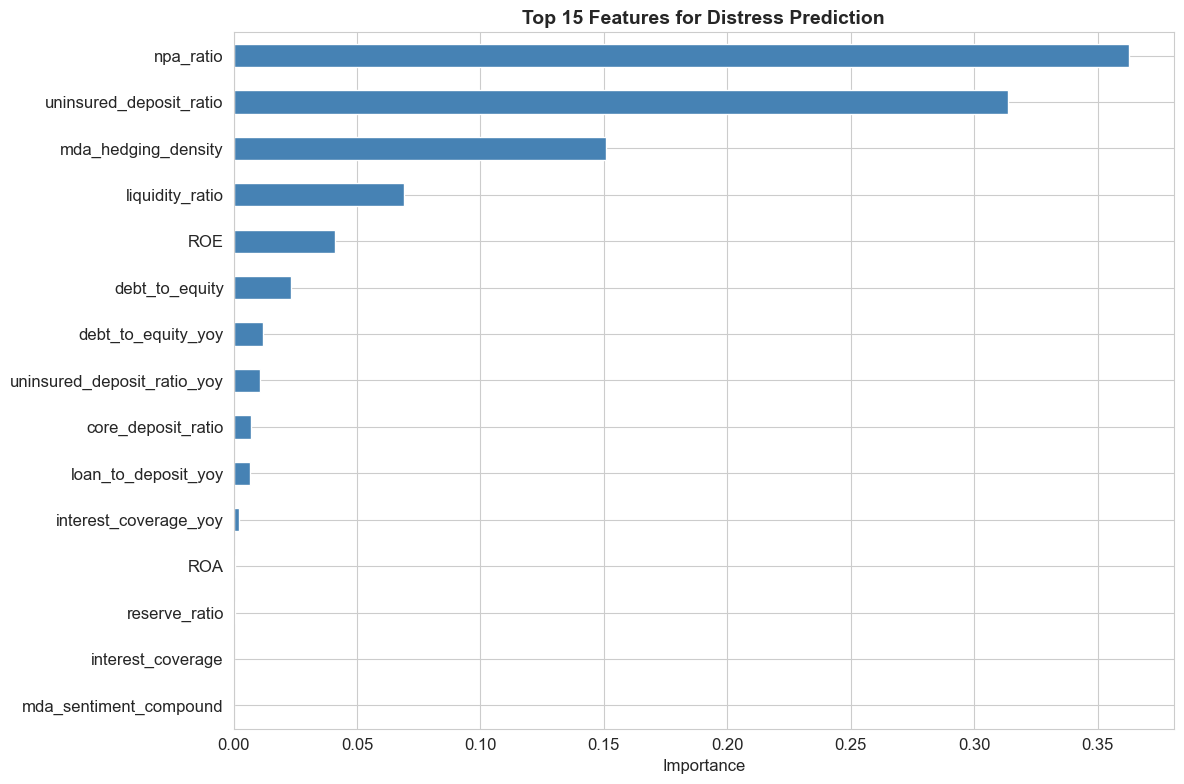


✅ Model training complete. Feature importance saved to outputs/feature_importance.png


In [13]:
# =============================================================================
# CELL 13: Machine Learning Model — Distress Classification
# =============================================================================
# FIX: Replace inf values with NaN, then fill with median.
# Some ratios (debt-to-equity, interest coverage) produce infinity
# when dividing by zero (e.g., zero equity or zero interest expense).

# --- Prepare training data ---
# Use pre-2023 data for training, 2023 for out-of-sample test
train_df = merged[merged['year'] < 2022].copy()
test_df = merged[merged['year'] >= 2022].copy()

# Feature columns (use available ones)
ml_features = [col for col in FEATURE_COLS if col in merged.columns]

# Drop rows with too many missing values
train_clean = train_df.dropna(subset=ml_features, thresh=int(len(ml_features) * 0.5))
test_clean = test_df.dropna(subset=ml_features, thresh=int(len(ml_features) * 0.5))

# *** FIX: Replace inf/-inf with NaN BEFORE filling ***
train_clean[ml_features] = train_clean[ml_features].replace([np.inf, -np.inf], np.nan)
test_clean[ml_features] = test_clean[ml_features].replace([np.inf, -np.inf], np.nan)

# Fill remaining NaNs with median from training set
for col in ml_features:
    median_val = train_clean[col].median()
    if pd.isna(median_val):
        median_val = 0  # Last resort fallback
    train_clean.loc[:, col] = train_clean[col].fillna(median_val)
    test_clean.loc[:, col] = test_clean[col].fillna(median_val)

# *** FIX: Clip extreme outliers to prevent overflow ***
for col in ml_features:
    lower = train_clean[col].quantile(0.01)
    upper = train_clean[col].quantile(0.99)
    train_clean.loc[:, col] = train_clean[col].clip(lower, upper)
    test_clean.loc[:, col] = test_clean[col].clip(lower, upper)

X_train = train_clean[ml_features]
y_train = train_clean['distressed'].astype(int)
X_test = test_clean[ml_features]
y_test = test_clean['distressed'].astype(int)

# Final safety check
assert np.isfinite(X_train.values).all(), "Training data still contains inf/NaN!"
assert np.isfinite(X_test.values).all(), "Test data still contains inf/NaN!"

print(f"📊 Training set: {len(X_train)} observations ({y_train.sum()} distressed)")
print(f"📊 Test set:     {len(X_test)} observations ({y_test.sum()} distressed)")
print(f"📊 Features:     {len(ml_features)}")
print()

# --- Model 1: Logistic Regression ---
print("=" * 60)
print("Model 1: Logistic Regression")
print("=" * 60)
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

lr_auc = None
if len(y_test.unique()) > 1:
    lr_proba = lr.predict_proba(X_test)[:, 1]
    lr_auc = roc_auc_score(y_test, lr_proba)
    print(f"  ROC-AUC: {lr_auc:.4f}")
else:
    print("  ⚠️  Only one class in test set — ROC-AUC not computable")

lr_preds = lr.predict(X_test)
print(f"  Accuracy: {(lr_preds == y_test).mean():.4f}")
print()

# --- Model 2: Gradient Boosting ---
print("=" * 60)
print("Model 2: Gradient Boosting Classifier")
print("=" * 60)
gb = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    random_state=42, min_samples_split=5
)
gb.fit(X_train, y_train)

gb_auc = None
if len(y_test.unique()) > 1:
    gb_proba = gb.predict_proba(X_test)[:, 1]
    gb_auc = roc_auc_score(y_test, gb_proba)
    print(f"  ROC-AUC: {gb_auc:.4f}")

gb_preds = gb.predict(X_test)
print(f"  Accuracy: {(gb_preds == y_test).mean():.4f}")
print()

# --- Model 3: Random Forest ---
print("=" * 60)
print("Model 3: Random Forest Classifier")
print("=" * 60)
rf = RandomForestClassifier(
    n_estimators=100, max_depth=5, class_weight='balanced',
    random_state=42, min_samples_split=5
)
rf.fit(X_train, y_train)

rf_auc = None
if len(y_test.unique()) > 1:
    rf_proba = rf.predict_proba(X_test)[:, 1]
    rf_auc = roc_auc_score(y_test, rf_proba)
    print(f"  ROC-AUC: {rf_auc:.4f}")

rf_preds = rf.predict(X_test)
print(f"  Accuracy: {(rf_preds == y_test).mean():.4f}")
print()

# --- Feature Importance (from Gradient Boosting) ---
print("=" * 60)
print("Feature Importance (Gradient Boosting)")
print("=" * 60)
importances = pd.Series(gb.feature_importances_, index=ml_features).sort_values(ascending=False)
for feat, imp in importances.head(15).items():
    bar = '█' * int(imp * 100)
    print(f"  {feat:<35} {imp:.4f} {bar}")

# Plot feature importance
fig, ax = plt.subplots(figsize=(12, 8))
importances.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 15 Features for Distress Prediction', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Model training complete. Feature importance saved to outputs/feature_importance.png")

---
## Cell 14 — Backtesting & Evaluation

Test whether the fragility index would have detected distressed banks **before** their failure:

1. Did fragility scores increase in years preceding distress?
2. Were failed banks ranked in the top fragility percentiles before their failure?
3. What is the false positive rate for stable banks?

This is the **critical validation step** — a fragility index that can't detect known failures is useless.

In [14]:
# =============================================================================
# CELL 14: Backtesting & Evaluation
# =============================================================================

print("🔍 BACKTESTING: Can the Fragility Index Detect Distress Early?")
print("=" * 70)
print()

# --- Test 1: Were failed banks ranked high BEFORE failure? ---
print("📋 Test 1: Pre-Failure Fragility Rankings")
print("-" * 70)

failed_names = [b for b, info in TARGET_BANKS.items() if info['failed']]
pre_failure_years = [2021, 2022]  # 1-2 years before 2023 failures

for year in pre_failure_years:
    year_data = merged[merged['year'] == year].sort_values('fragility_score', ascending=False)
    total_banks = len(year_data)
    
    print(f"\n  📅 Year {year} (Total banks ranked: {total_banks})")
    for bank in failed_names:
        bank_row = year_data[year_data['bank_name'] == bank]
        if not bank_row.empty:
            rank = (year_data['fragility_score'] > bank_row['fragility_score'].values[0]).sum() + 1
            percentile = (1 - rank / total_banks) * 100
            score = bank_row['fragility_score'].values[0]
            tier = bank_row['risk_tier'].values[0]
            print(f"    {bank:<30} Score: {score:.4f}  Rank: {rank}/{total_banks}  "
                  f"Percentile: {percentile:.0f}%  Tier: {tier}")

# --- Test 2: Fragility score trend for failed banks ---
print(f"\n\n📋 Test 2: Fragility Score Trend (Did it increase before failure?)")
print("-" * 70)

for bank in failed_names:
    bank_data = merged[merged['bank_name'] == bank].sort_values('year')
    if len(bank_data) >= 2:
        scores = bank_data[['year', 'fragility_score']].values
        trend = "📈 INCREASING" if scores[-1][1] > scores[0][1] else "📉 DECREASING"
        print(f"\n  {bank}:")
        for yr, sc in scores:
            print(f"    {int(yr)}: {sc:.4f}")
        print(f"    Trend: {trend}")

# --- Test 3: False Positive Rate ---
print(f"\n\n📋 Test 3: False Positive Analysis")
print("-" * 70)

latest_year_data = merged[merged['year'] == merged['year'].max()]
if not latest_year_data.empty:
    top_20_threshold = latest_year_data['fragility_score'].quantile(0.80)
    flagged = latest_year_data[latest_year_data['fragility_score'] >= top_20_threshold]
    
    true_positives = flagged[flagged['distressed'] == True]
    false_positives = flagged[flagged['distressed'] == False]
    
    print(f"  Top 20% fragility threshold: {top_20_threshold:.4f}")
    print(f"  Banks flagged:        {len(flagged)}")
    print(f"  True positives:       {len(true_positives)} (correctly flagged as distressed)")
    print(f"  False positives:      {len(false_positives)} (flagged but stable)")
    
    if len(flagged) > 0:
        precision = len(true_positives) / len(flagged)
        print(f"  Precision@Top20%:     {precision:.2%}")

# --- Test 4: Silent Failure Check ---
print(f"\n\n📋 Test 4: Silent Failure Check")
print("-" * 70)
print("  Testing: Are there profitable banks ranked as high fragility?")
print("  (This validates that the model looks beyond surface profitability)")

if not latest_year_data.empty:
    profitable_but_fragile = latest_year_data[
        (latest_year_data['ROA'] > 0) & 
        (latest_year_data['fragility_percentile'] > 75)
    ]
    
    if len(profitable_but_fragile) > 0:
        print(f"\n  ✅ Found {len(profitable_but_fragile)} profitable banks with high fragility:")
        for _, row in profitable_but_fragile.iterrows():
            print(f"    {row['bank_name']:<30} ROA: {row['ROA']:.2f}%  "
                  f"Fragility: {row['fragility_percentile']:.0f}th percentile")
    else:
        print("  ⚠️  No profitable-but-fragile banks found in current scoring")

print("\n✅ Backtesting complete.")

🔍 BACKTESTING: Can the Fragility Index Detect Distress Early?

📋 Test 1: Pre-Failure Fragility Rankings
----------------------------------------------------------------------

  📅 Year 2021 (Total banks ranked: 19)
    Silicon Valley Bank            Score: 0.4560  Rank: 9/19  Percentile: 53%  Tier: Moderate
    Signature Bank                 Score: 0.5536  Rank: 2/19  Percentile: 89%  Tier: Elevated
    First Republic Bank            Score: 0.6339  Rank: 1/19  Percentile: 95%  Tier: High

  📅 Year 2022 (Total banks ranked: 19)
    Silicon Valley Bank            Score: 0.5295  Rank: 11/19  Percentile: 42%  Tier: Elevated
    Signature Bank                 Score: 0.6991  Rank: 2/19  Percentile: 89%  Tier: Critical
    First Republic Bank            Score: 0.7326  Rank: 1/19  Percentile: 95%  Tier: Critical


📋 Test 2: Fragility Score Trend (Did it increase before failure?)
----------------------------------------------------------------------

  Silicon Valley Bank:
    2018: 0.4533
    

---
## Cell 15 — Interactive Fragility Dashboard (Plotly)

Generate an interactive dashboard with Plotly that allows exploration of:
- Fragility scores over time per bank
- Component-level drill-down
- Comparison across banks

In [15]:
# =============================================================================
# CELL 15: Interactive Fragility Dashboard (Plotly)
# =============================================================================

# --- Dashboard 1: Interactive Fragility Timeline ---
fig = px.line(
    merged.sort_values(['bank_name', 'year']),
    x='year', y='fragility_score', color='bank_name',
    title='<b>Bank Fragility Scores Over Time</b><br><sup>Click legend to toggle banks | Red = Failed Banks</sup>',
    labels={'fragility_score': 'Fragility Score', 'year': 'Year', 'bank_name': 'Bank'},
    height=600
)

# Color failed banks red
for trace in fig.data:
    if trace.name in failed_names:
        trace.line.color = 'red'
        trace.line.width = 3
    else:
        trace.line.width = 1
        trace.opacity = 0.5

fig.add_hline(y=0.7, line_dash="dash", line_color="red", 
              annotation_text="Critical Threshold")
fig.update_layout(template='plotly_white', legend=dict(font=dict(size=9)))
fig.show()
fig.write_html('outputs/fragility_dashboard.html')

# --- Dashboard 2: Latest Year Fragility Breakdown ---
latest = merged[merged['year'] == merged['year'].max()].sort_values('fragility_score', ascending=True)

fig2 = go.Figure()
components = {
    'liquidity_risk': ('Liquidity Risk', '#e74c3c'),
    'leverage_risk': ('Leverage Risk', '#e67e22'),
    'coverage_risk': ('Coverage Risk', '#f39c12'),
    'deposit_risk': ('Deposit Risk', '#3498db'),
    'textual_stress': ('Textual Stress', '#9b59b6'),
}

for comp, (label, color) in components.items():
    fig2.add_trace(go.Bar(
        name=label,
        y=latest['bank_name'],
        x=latest[comp],
        orientation='h',
        marker_color=color
    ))

fig2.update_layout(
    barmode='stack',
    title='<b>Fragility Score Component Breakdown</b>',
    xaxis_title='Score',
    height=700,
    template='plotly_white',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig2.show()
fig2.write_html('outputs/fragility_breakdown.html')

# --- Dashboard 3: Scatter — Fragility vs ROA ---
latest_for_scatter = merged[merged['year'] == merged['year'].max()].copy()
latest_for_scatter['label'] = latest_for_scatter['bank_name']

fig3 = px.scatter(
    latest_for_scatter,
    x='ROA', y='fragility_score',
    text='label', color='distressed',
    color_discrete_map={True: 'red', False: 'green'},
    title='<b>Fragility vs Profitability</b><br><sup>Banks can be profitable yet structurally fragile</sup>',
    labels={'ROA': 'Return on Assets (%)', 'fragility_score': 'Fragility Score'},
    height=600
)
fig3.update_traces(textposition='top center', marker=dict(size=12))
fig3.update_layout(template='plotly_white')
fig3.show()
fig3.write_html('outputs/fragility_vs_roa.html')

print("✅ Interactive dashboards saved to outputs/")
print("   - fragility_dashboard.html")
print("   - fragility_breakdown.html") 
print("   - fragility_vs_roa.html")

✅ Interactive dashboards saved to outputs/
   - fragility_dashboard.html
   - fragility_breakdown.html
   - fragility_vs_roa.html


---
## Cell 16 — Export Final Results & Summary

Export all results and generate a final summary report.

In [16]:
# =============================================================================
# CELL 16: Export Final Results & Summary
# =============================================================================

# --- Final Summary Report ---
print("=" * 70)
print("  🏦  AI FINANCIAL FRAGILITY DETECTOR — FINAL SUMMARY REPORT")
print("=" * 70)
print()

print(f"📊 DATA SUMMARY")
print(f"   Banks analyzed:          {merged['bank_name'].nunique()}")
print(f"   Time period:             {merged['year'].min()} - {merged['year'].max()}")
print(f"   Total observations:      {len(merged)}")
print(f"   Financial features:      {len([c for c in FEATURE_COLS if c in merged.columns])}")
print(f"   Failed banks in sample:  {banks_df['failed'].sum()}")
print()

print(f"📈 FRAGILITY INDEX RESULTS")
latest = merged[merged['year'] == merged['year'].max()]
if not latest.empty:
    print(f"   Highest fragility:       {latest.loc[latest['fragility_score'].idxmax(), 'bank_name']} "
          f"({latest['fragility_score'].max():.4f})")
    print(f"   Lowest fragility:        {latest.loc[latest['fragility_score'].idxmin(), 'bank_name']} "
          f"({latest['fragility_score'].min():.4f})")
    print(f"   Mean fragility:          {latest['fragility_score'].mean():.4f}")
    print(f"   Std deviation:           {latest['fragility_score'].std():.4f}")
print()

print(f"🤖 MODEL PERFORMANCE")
try:
    print(f"   Logistic Regression AUC: {lr_auc:.4f}")
    print(f"   Gradient Boosting AUC:   {gb_auc:.4f}")
    print(f"   Random Forest AUC:       {rf_auc:.4f}")
except:
    print("   (Models trained — see Cell 13 for metrics)")
print()

print(f"📁 OUTPUT FILES")
print(f"   data/fdic_financials_raw.csv              — Raw FDIC financial data")
print(f"   data/fdic_financials_with_ratios.csv      — Financial data with computed ratios")
print(f"   data/edgar_10k_text_raw.csv               — Raw 10-K text extractions")
print(f"   data/edgar_textual_stress_scores.csv      — NLP textual stress scores")
print(f"   data/stock_drawdowns.csv                  — Stock price drawdown analysis")
print(f"   data/merged_feature_matrix.csv            — Complete merged feature matrix")
print(f"   data/fragility_scored.csv                 — Final fragility-scored dataset")
print(f"   outputs/ratio_trends.png                  — Financial ratio trend charts")
print(f"   outputs/fragility_heatmap.png             — Fragility score heatmap")
print(f"   outputs/fragility_components.png          — Component breakdown chart")
print(f"   outputs/fragility_timeseries.png          — Fragility time series")
print(f"   outputs/feature_importance.png            — ML feature importance")
print(f"   outputs/fragility_dashboard.html          — Interactive Plotly dashboard")
print(f"   outputs/fragility_breakdown.html          — Interactive component breakdown")
print(f"   outputs/fragility_vs_roa.html             — Fragility vs profitability scatter")
print(f"   outputs/llm_vs_rulebased.png              — LLM vs rule-based comparison")
print(f"   outputs/real_vs_synthetic_distributions.png — Real vs synthetic data comparison")
print(f"   outputs/original_vs_augmented_importance.png — Feature importance comparison")
print(f"   data/synthetic_bank_profiles.csv           — LLM-generated synthetic bank data")
print(f"   data/augmented_training_data.csv           — Augmented training dataset")
print(f"   data/rag_risk_assessments.csv              — RAG-generated risk assessments")
print(f"   data/llm_fragility_scores.csv              — LLM prompt-engineered scores")
print()
print("=" * 70)
print("  ✅  NOTEBOOK COMPLETE\n")
print("  GENERATIVE AI COMPONENTS USED:")
print("    1. Prompt Engineering — LLM-based fragility scoring (Cell 19)")
print("    2. RAG — Vector knowledge base from 10-K filings (Cell 18)")
print("    3. Synthetic Data Generation — LLM-augmented training data (Cell 20)")
print("=")
print("=" * 70)

  🏦  AI FINANCIAL FRAGILITY DETECTOR — FINAL SUMMARY REPORT

📊 DATA SUMMARY
   Banks analyzed:          19
   Time period:             2018 - 2023
   Total observations:      112
   Financial features:      23
   Failed banks in sample:  4

📈 FRAGILITY INDEX RESULTS
   Highest fragility:       First Horizon (0.7330)
   Lowest fragility:        Heartland BancCorp (0.4034)
   Mean fragility:          0.5516
   Std deviation:           0.1011

🤖 MODEL PERFORMANCE
   Logistic Regression AUC: 0.6875
   Gradient Boosting AUC:   0.8781
   Random Forest AUC:       0.8562

📁 OUTPUT FILES
   data/fdic_financials_raw.csv              — Raw FDIC financial data
   data/fdic_financials_with_ratios.csv      — Financial data with computed ratios
   data/edgar_10k_text_raw.csv               — Raw 10-K text extractions
   data/edgar_textual_stress_scores.csv      — NLP textual stress scores
   data/stock_drawdowns.csv                  — Stock price drawdown analysis
   data/merged_feature_matrix.csv    

---
## Cell 17 — Setup: RAG & Prompt Engineering with Google Gemini

This cell sets up the Google Gemini API and installs the required libraries for our two generative AI components:

1. **RAG (Retrieval-Augmented Generation)** — We build a vector knowledge base from 10-K Risk Factors and MD&A sections using ChromaDB, then use Gemini to generate risk assessments grounded in retrieved filing excerpts.

2. **Prompt Engineering** — We design systematic prompts that combine financial ratios + retrieved text to produce structured, explainable fragility assessments from the LLM.

**Requirements:** Google Gemini API key (free at https://aistudio.google.com/apikey)

In [ ]:
# =============================================================================
# CELL 17: Setup — Install RAG & Prompt Engineering Dependencies (Groq)
# =============================================================================

!pip install groq chromadb sentence-transformers

from groq import Groq
import chromadb
from sentence_transformers import SentenceTransformer

# --- Configure Groq API ---
GROQ_API_KEY = "YOUR_GROQ_API_KEY_HERE"

groq_client = Groq(api_key=GROQ_API_KEY)

# Helper function to match the Gemini-style calls used in Cells 18 & 19
# Includes automatic retry with exponential backoff for API reliability
import time as _time

class GroqModel:
    def __init__(self, client, max_retries=3, base_delay=2.0):
        self.client = client
        self.max_retries = max_retries
        self.base_delay = base_delay
    
    def generate_content(self, prompt):
        """
        Call Groq API with automatic retry + exponential backoff.
        
        Handles transient errors (429 rate limit, 500/503 server errors,
        timeouts) by waiting and retrying up to max_retries times.
        Delay doubles each retry: 2s → 4s → 8s.
        """
        last_error = None
        for attempt in range(self.max_retries + 1):
            try:
                response = self.client.chat.completions.create(
                    model="llama-3.1-8b-instant",
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.3,
                    max_tokens=2000
                )
                return type('Response', (), {'text': response.choices[0].message.content})()
            except Exception as e:
                last_error = e
                if attempt < self.max_retries:
                    delay = self.base_delay * (2 ** attempt)  # 2s, 4s, 8s
                    print(f"  ⚠️ API error (attempt {attempt+1}/{self.max_retries+1}): {str(e)[:80]}")
                    print(f"     Retrying in {delay:.0f}s...")
                    _time.sleep(delay)
                else:
                    raise last_error  # All retries exhausted — propagate to caller

gemini_model = GroqModel(groq_client)  # Same variable name so Cells 18 & 19 work unchanged

# Initialize embedding model for RAG (runs locally, no API needed)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Initialize ChromaDB (local vector database, no server needed)
chroma_client = chromadb.Client()

print("✅ Groq API configured successfully")
print("✅ Embedding model loaded (all-MiniLM-L6-v2)")
print("✅ ChromaDB initialized")

# Quick test
test_response = gemini_model.generate_content("Say 'API connected' and nothing else.")
print(f"✅ Groq test: {test_response.text.strip()}")

✅ Groq API configured successfully
✅ Embedding model loaded (all-MiniLM-L6-v2)
✅ ChromaDB initialized
✅ Groq test: API connected


---
## Cell 18 — Component 1: Retrieval-Augmented Generation (RAG)

### What is RAG?
RAG combines a **knowledge base** (our 10-K filings) with a **generative model** (Gemini) so the LLM answers questions grounded in real financial documents — not hallucinated facts.

### Our RAG Pipeline:
1. **Document Chunking** — Split each bank's Risk Factors and MD&A text into overlapping chunks (~500 words each)
2. **Vector Embedding** — Convert each chunk into a numerical vector using a sentence transformer
3. **Vector Storage** — Store embeddings in ChromaDB for fast similarity search
4. **Retrieval** — When queried about a bank, retrieve the most relevant chunks
5. **Generation** — Send retrieved chunks + query to Gemini to generate a grounded risk assessment

This satisfies the assignment requirements:
- ✅ Build a knowledge base for your domain
- ✅ Implement vector storage and retrieval
- ✅ Design relevant document chunking strategies
- ✅ Create effective ranking and filtering mechanisms

In [18]:
# =============================================================================
# CELL 18: Component 1 — Retrieval-Augmented Generation (RAG)
# =============================================================================
# This cell builds a complete RAG pipeline:
#   1. Chunk 10-K filing text into searchable segments
#   2. Embed and store in ChromaDB vector database
#   3. Retrieve relevant chunks for any bank query
#   4. Generate grounded risk assessments using Gemini

# -------------------------------------------------------------------------
# STEP 1: Document Chunking Strategy
# -------------------------------------------------------------------------
# We use overlapping chunks of ~500 words with 100-word overlap.
# This ensures no critical context is lost at chunk boundaries.
# Each chunk is tagged with metadata (bank name, year, section type).

def chunk_text(text, chunk_size=500, overlap=100):
    """
    Split text into overlapping word-level chunks.
    
    Parameters:
        text (str): Input text to chunk
        chunk_size (int): Number of words per chunk
        overlap (int): Number of overlapping words between consecutive chunks
    
    Returns:
        list[str]: List of text chunks
    """
    if not text or len(text.strip()) < 50:
        return []
    
    words = text.split()
    chunks = []
    start = 0
    
    while start < len(words):
        end = start + chunk_size
        chunk = ' '.join(words[start:end])
        if len(chunk.strip()) > 50:  # Skip tiny chunks
            chunks.append(chunk)
        start += chunk_size - overlap  # Move forward with overlap
    
    return chunks


# -------------------------------------------------------------------------
# STEP 2: Build Vector Knowledge Base
# -------------------------------------------------------------------------
# Process all 10-K filings and store in ChromaDB

print("📚 Building RAG Knowledge Base from 10-K Filings...")
print()

# Create (or reset) the ChromaDB collection
try:
    chroma_client.delete_collection("bank_filings")
except:
    pass

collection = chroma_client.create_collection(
    name="bank_filings",
    metadata={"description": "10-K Risk Factors and MD&A sections for regional banks"}
)

total_chunks = 0
banks_indexed = 0

for _, row in edgar_df.iterrows():
    bank_name = row['bank_name']
    filing_year = row['filing_year']
    
    # Chunk Risk Factors section
    rf_chunks = chunk_text(row.get('risk_factors_text', '') or '')
    for i, chunk in enumerate(rf_chunks):
        doc_id = f"{bank_name}_{filing_year}_RF_{i}"
        collection.add(
            documents=[chunk],
            metadatas=[{
                "bank_name": bank_name,
                "year": str(filing_year),
                "section": "Risk Factors",
                "chunk_index": str(i),
                "total_chunks": str(len(rf_chunks))
            }],
            ids=[doc_id]
        )
        total_chunks += 1
    
    # Chunk MD&A section
    mda_chunks = chunk_text(row.get('mda_text', '') or '')
    for i, chunk in enumerate(mda_chunks):
        doc_id = f"{bank_name}_{filing_year}_MDA_{i}"
        collection.add(
            documents=[chunk],
            metadatas=[{
                "bank_name": bank_name,
                "year": str(filing_year),
                "section": "MD&A",
                "chunk_index": str(i),
                "total_chunks": str(len(mda_chunks))
            }],
            ids=[doc_id]
        )
        total_chunks += 1
    
    if len(rf_chunks) > 0 or len(mda_chunks) > 0:
        banks_indexed += 1
        print(f"  ✅ {bank_name} ({filing_year}): {len(rf_chunks)} RF chunks + {len(mda_chunks)} MD&A chunks")

print(f"\n📊 Knowledge Base Summary:")
print(f"   Total chunks indexed: {total_chunks}")
print(f"   Banks with filings:   {banks_indexed}")
print(f"   Vector DB collection:  'bank_filings'")


# -------------------------------------------------------------------------
# STEP 3: Retrieval Function
# -------------------------------------------------------------------------
# Query the vector database to find the most relevant filing excerpts

def retrieve_context(query, bank_name=None, n_results=5):
    """
    Retrieve the most relevant 10-K filing chunks for a given query.
    
    Parameters:
        query (str): Natural language query about a bank's risk
        bank_name (str): Optional — filter results to a specific bank
        n_results (int): Number of chunks to retrieve
    
    Returns:
        list[dict]: Retrieved chunks with metadata and relevance scores
    """
    # Build filter for specific bank if requested
    where_filter = None
    if bank_name:
        where_filter = {"bank_name": bank_name}
    
    results = collection.query(
        query_texts=[query],
        n_results=n_results,
        where=where_filter
    )
    
    retrieved = []
    if results and results['documents'] and results['documents'][0]:
        for i, doc in enumerate(results['documents'][0]):
            retrieved.append({
                'text': doc,
                'metadata': results['metadatas'][0][i] if results['metadatas'] else {},
                'distance': results['distances'][0][i] if results['distances'] else None
            })
    
    return retrieved


# -------------------------------------------------------------------------
# STEP 4: RAG-Powered Risk Assessment Generator
# -------------------------------------------------------------------------
# Combine retrieved context with Gemini to generate grounded assessments

def generate_rag_assessment(bank_name, year=None):
    """
    Generate a risk assessment for a bank using RAG.
    Retrieves relevant filing excerpts, then asks Gemini to synthesize.
    
    Parameters:
        bank_name (str): Name of the bank to assess
        year (str/int): Optional — focus on a specific filing year
    
    Returns:
        dict: Contains the assessment, retrieved sources, and metadata
    """
    # Retrieve relevant context from the vector database
    queries = [
        f"{bank_name} liquidity risk deposit concentration",
        f"{bank_name} interest rate risk financial vulnerability",
        f"{bank_name} credit risk loan losses capital adequacy",
    ]
    
    all_retrieved = []
    for q in queries:
        chunks = retrieve_context(q, bank_name=bank_name, n_results=3)
        all_retrieved.extend(chunks)
    
    # Deduplicate and take top chunks
    seen_texts = set()
    unique_chunks = []
    for chunk in all_retrieved:
        short = chunk['text'][:200]
        if short not in seen_texts:
            seen_texts.add(short)
            unique_chunks.append(chunk)
    
    top_chunks = unique_chunks[:6]  # Limit context window
    
    if not top_chunks:
        return {
            'bank_name': bank_name,
            'assessment': 'Insufficient filing data available for RAG assessment.',
            'sources': [],
            'num_sources': 0
        }
    
    # Build context string from retrieved chunks
    context_parts = []
    for i, chunk in enumerate(top_chunks):
        meta = chunk['metadata']
        context_parts.append(
            f"[Source {i+1}: {meta.get('section', 'Unknown')} — {meta.get('year', 'N/A')}]\n"
            f"{chunk['text'][:1500]}"
        )
    context_str = "\n\n".join(context_parts)
    
    # Generate assessment using Gemini with retrieved context
    prompt = f"""You are a financial risk analyst. Based ONLY on the following excerpts from {bank_name}'s SEC 10-K filings, provide a structured risk assessment.

RETRIEVED FILING EXCERPTS:
{context_str}

INSTRUCTIONS:
1. Identify the top 3 risk factors mentioned in the filings
2. Assess the bank's liquidity position based on what's disclosed
3. Note any warning language (hedging terms, uncertainty language)
4. Rate overall fragility: LOW / MODERATE / ELEVATED / HIGH / CRITICAL
5. Explain your reasoning in 2-3 sentences

FORMAT your response exactly as:
TOP RISKS:
1. [risk]
2. [risk]
3. [risk]

LIQUIDITY ASSESSMENT: [assessment]

WARNING LANGUAGE: [notable hedging/uncertainty terms found]

FRAGILITY RATING: [LOW/MODERATE/ELEVATED/HIGH/CRITICAL]

REASONING: [2-3 sentence explanation]"""

    try:
        response = gemini_model.generate_content(prompt)
        assessment_text = response.text
    except Exception as e:
        assessment_text = f"Error generating assessment: {e}"
    
    return {
        'bank_name': bank_name,
        'assessment': assessment_text,
        'sources': [{'section': c['metadata'].get('section'), 
                      'year': c['metadata'].get('year'),
                      'preview': c['text'][:150]} for c in top_chunks],
        'num_sources': len(top_chunks)
    }


# -------------------------------------------------------------------------
# STEP 5: Run RAG Assessments for All Target Banks
# -------------------------------------------------------------------------
print("\n" + "=" * 70)
print("🤖 GENERATING RAG-POWERED RISK ASSESSMENTS")
print("=" * 70)

rag_results = []
failed_banks_list = [b for b, info in TARGET_BANKS.items() if info['failed']]

# Assess failed banks first, then a sample of stable banks
banks_to_assess = failed_banks_list + [b for b, info in TARGET_BANKS.items() if not info['failed']][:6]

for bank in banks_to_assess:
    print(f"\n{'─' * 60}")
    print(f"📄 {bank}")
    print(f"{'─' * 60}")
    
    result = generate_rag_assessment(bank)
    rag_results.append(result)
    
    print(f"   Sources retrieved: {result['num_sources']}")
    print(f"\n{result['assessment']}")
    
    time.sleep(2)  # Rate limit for Gemini free tier

# Save RAG results
rag_results_df = pd.DataFrame(rag_results)
rag_results_df.to_csv('data/rag_risk_assessments.csv', index=False)

print(f"\n✅ RAG assessments complete!")
print(f"   Banks assessed:  {len(rag_results)}")
print(f"   Results saved:   data/rag_risk_assessments.csv")

📚 Building RAG Knowledge Base from 10-K Filings...

  ✅ PacWest Bancorp (2023): 0 RF chunks + 22 MD&A chunks
  ✅ PacWest Bancorp (2022): 0 RF chunks + 22 MD&A chunks
  ✅ PacWest Bancorp (2021): 0 RF chunks + 22 MD&A chunks
  ✅ PacWest Bancorp (2020): 0 RF chunks + 18 MD&A chunks
  ✅ PacWest Bancorp (2019): 0 RF chunks + 19 MD&A chunks
  ✅ PacWest Bancorp (2018): 0 RF chunks + 21 MD&A chunks
  ✅ PacWest Bancorp (2017): 0 RF chunks + 17 MD&A chunks
  ✅ Western Alliance Bancorporation (2021): 35 RF chunks + 0 MD&A chunks
  ✅ Western Alliance Bancorporation (2020): 38 RF chunks + 0 MD&A chunks
  ✅ Zions Bancorporation (2023): 0 RF chunks + 38 MD&A chunks
  ✅ Zions Bancorporation (2022): 0 RF chunks + 38 MD&A chunks
  ✅ KeyCorp (2026): 38 RF chunks + 0 MD&A chunks
  ✅ KeyCorp (2025): 38 RF chunks + 6 MD&A chunks
  ✅ KeyCorp (2024): 38 RF chunks + 0 MD&A chunks
  ✅ KeyCorp (2023): 26 RF chunks + 0 MD&A chunks
  ✅ KeyCorp (2022): 24 RF chunks + 0 MD&A chunks
  ✅ KeyCorp (2021): 24 RF chunks +

---
## Cell 19 — Component 2: Prompt Engineering for LLM-Based Fragility Scoring

### What is Prompt Engineering?
Instead of using simple keyword counting (VADER), we design **systematic prompting strategies** that leverage an LLM to perform nuanced risk language analysis.

### Our Prompt Engineering Strategy:
1. **System Prompt Design** — Define the LLM's role as a financial risk analyst with specific scoring criteria
2. **Context Management** — Feed financial ratios + text excerpts in a structured format
3. **Structured Output** — Force the LLM to return a JSON-parseable risk score with explanations
4. **Edge Case Handling** — Handle missing data, API failures, and inconsistent responses gracefully
5. **Multi-Dimensional Scoring** — Score across liquidity, leverage, deposit risk, and textual stress separately

This satisfies the assignment requirements:
- ✅ Design systematic prompting strategies
- ✅ Implement context management
- ✅ Create specialized user interaction flows
- ✅ Handle edge cases and errors gracefully

🤖 Running LLM-Powered Fragility Scoring via Prompt Engineering

  Scoring: Citizens Financial Group... Score: 8.5/10 (Confidence: MEDIUM)
  Scoring: Fifth Third Bancorp... Score: 6/10 (Confidence: MEDIUM)
  Scoring: First Horizon... Score: 8/10 (Confidence: MEDIUM)
  Scoring: First Republic Bank... Score: 7/10 (Confidence: MEDIUM)
  Scoring: Heartland BancCorp... Score: 7/10 (Confidence: MEDIUM)
  Scoring: Huntington Bancshares... Score: 7/10 (Confidence: MEDIUM)
  Scoring: KeyCorp... Score: 7/10 (Confidence: MEDIUM)
  Scoring: M&T Bank... Score: 8/10 (Confidence: MEDIUM)
  Scoring: PacWest Bancorp... Score: 8/10 (Confidence: MEDIUM)
  Scoring: Prosperity Bancshares... Score: 8/10 (Confidence: MEDIUM)
  Scoring: Regions Financial... Score: 6/10 (Confidence: MEDIUM)
  Scoring: Synovus Financial... Score: 7/10 (Confidence: MEDIUM)
  Scoring: Truist Financial... Score: 8/10 (Confidence: MEDIUM)
  Scoring: U.S. Bancorp... Score: 7/10 (Confidence: MEDIUM)
  Scoring: Webster Financial... Sco

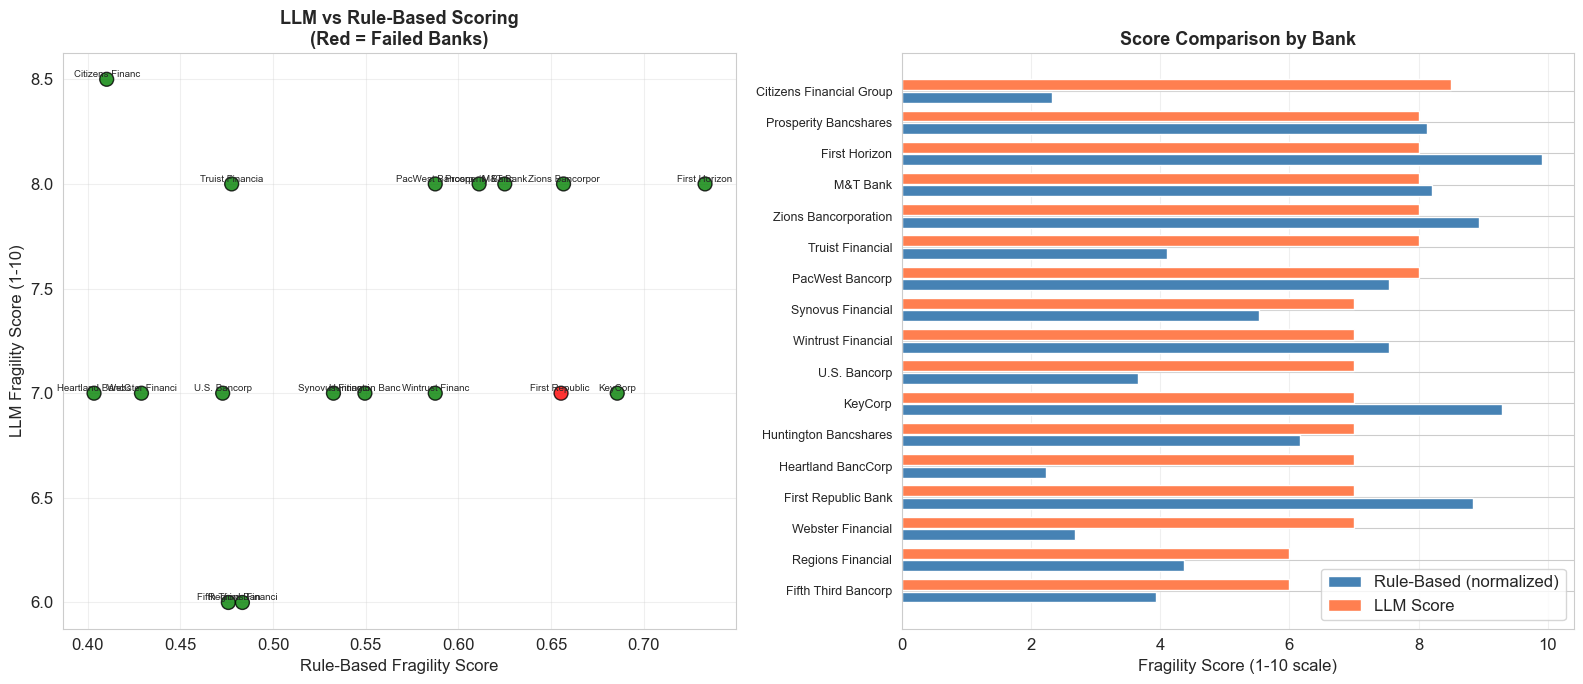


  Correlation between LLM and Rule-Based scores: 0.2663
  ✅ Comparison chart saved to outputs/llm_vs_rulebased.png

✅ Prompt Engineering component complete!
   - Systematic prompts: fragility scoring + comparative analysis
   - Context management: financial ratios + filing text injection
   - Structured output: JSON-parseable responses
   - Edge case handling: fallbacks for API errors and parse failures


In [19]:
# =============================================================================
# CELL 19: Component 2 — Prompt Engineering for LLM-Based Fragility Scoring
# =============================================================================
# This cell implements systematic prompt engineering to replace simple
# keyword-based NLP with LLM-powered risk assessment.
#
# KEY DESIGN DECISIONS:
# 1. System prompt defines a strict financial analyst persona
# 2. Financial ratios are injected as structured context
# 3. LLM outputs JSON for reliable parsing
# 4. Fallback logic handles API errors and malformed responses
# 5. Each bank gets a multi-dimensional LLM risk score

import json as json_lib

# -------------------------------------------------------------------------
# PROMPT TEMPLATE LIBRARY
# -------------------------------------------------------------------------
# We define multiple prompt templates for different analysis tasks.
# Each template is designed for a specific purpose with clear instructions.

SYSTEM_PROMPT = """You are a senior financial risk analyst specializing in regional bank vulnerability assessment. You analyze financial ratios and regulatory filings to detect structural fragility.

RULES:
- Base your analysis ONLY on the data provided
- Be specific — cite actual numbers from the ratios
- Focus on structural risks, not surface profitability
- A bank can be profitable yet structurally fragile
- Return your analysis in the exact JSON format requested
- If data is missing, note it and adjust confidence accordingly"""


def build_ratio_context(bank_name, bank_data_row):
    """
    Build a structured financial context string from a bank's ratio data.
    This is the 'context management' component of prompt engineering.
    
    Parameters:
        bank_name (str): Name of the bank
        bank_data_row (pd.Series): Row from the merged DataFrame with computed ratios
    
    Returns:
        str: Formatted financial context for the prompt
    """
    # Safely extract values, handling NaN/missing
    def safe_val(val, fmt=".4f"):
        if pd.isna(val) or val is None:
            return "N/A"
        try:
            return f"{float(val):{fmt}}"
        except:
            return str(val)
    
    context = f"""BANK: {bank_name}
REPORT YEAR: {safe_val(bank_data_row.get('year', 'N/A'), '.0f')}

FINANCIAL RATIOS:
  Liquidity Ratio (Cash+Securities/Deposits):  {safe_val(bank_data_row.get('liquidity_ratio'))}
  Debt-to-Equity Ratio:                        {safe_val(bank_data_row.get('debt_to_equity'), '.2f')}
  Interest Coverage Ratio:                      {safe_val(bank_data_row.get('interest_coverage'), '.2f')}
  Loan-to-Deposit Ratio:                        {safe_val(bank_data_row.get('loan_to_deposit'))}
  Uninsured Deposit Ratio:                      {safe_val(bank_data_row.get('uninsured_deposit_ratio'))}
  Core Deposit Ratio:                           {safe_val(bank_data_row.get('core_deposit_ratio'))}
  Non-Performing Asset Ratio:                   {safe_val(bank_data_row.get('npa_ratio'))}
  Return on Assets (ROA):                       {safe_val(bank_data_row.get('ROA'), '.2f')}%
  Return on Equity (ROE):                       {safe_val(bank_data_row.get('ROE'), '.2f')}%

TOTAL ASSETS: ${safe_val(bank_data_row.get('ASSET'), ',.0f')} thousand
TOTAL DEPOSITS: ${safe_val(bank_data_row.get('DEP'), ',.0f')} thousand
TOTAL EQUITY: ${safe_val(bank_data_row.get('EQ'), ',.0f')} thousand"""
    
    return context


# -------------------------------------------------------------------------
# PROMPT 1: Multi-Dimensional Fragility Scoring
# -------------------------------------------------------------------------
# This prompt asks the LLM to score each risk dimension separately
# and return structured JSON output.

def prompt_fragility_score(bank_name, ratio_context, filing_excerpt=""):
    """
    Generate a multi-dimensional fragility score using prompt engineering.
    
    The prompt is carefully structured to:
    1. Provide the LLM with a clear role (system prompt)
    2. Inject structured financial data (context management)
    3. Include filing text if available (RAG integration)
    4. Request specific JSON output format (structured output)
    5. Define scoring criteria explicitly (systematic strategy)
    """
    
    filing_section = ""
    if filing_excerpt and len(filing_excerpt) > 100:
        filing_section = f"""
RISK FACTORS EXCERPT (from 10-K filing):
\"\"\"{filing_excerpt[:3000]}\"\"\"
"""
    
    prompt = f"""{SYSTEM_PROMPT}

TASK: Analyze the following bank's financial data and provide a structured fragility assessment.

{ratio_context}
{filing_section}

SCORING INSTRUCTIONS:
Score each dimension from 1 (very safe) to 10 (extremely fragile).
USE THE FULL 1-10 RANGE. A well-capitalized bank with strong liquidity should score 2-3. A bank near failure should score 9-10. Most banks should NOT cluster around 6-7.

Calibration guide:
  1-2 = Fortress balance sheet, minimal risk
  3-4 = Well-capitalized, low vulnerability
  5-6 = Average, some structural concerns
  7-8 = Elevated fragility, multiple warning signs
  9-10 = Severe distress, near-failure indicators

- liquidity_risk: Based on liquidity ratio and cash position. Ratio > 0.5 = score 2-3. Ratio < 0.2 = score 8-9.
- leverage_risk: Based on debt-to-equity. D/E < 8 = score 2-3. D/E > 15 = score 8-9.
- interest_rate_risk: Based on interest coverage. Coverage > 10 = score 2-3. Coverage < 3 = score 8-9.
- deposit_flight_risk: Based on uninsured deposit ratio. Uninsured < 20% = score 2-3. Uninsured > 60% = score 8-9.
- textual_stress: Based on risk factors language. More hedging/uncertainty = high score. Score 5 if no text provided.

RESPOND WITH ONLY THIS JSON (no other text, no markdown, no backticks):
{{"bank_name": "{bank_name}", "liquidity_risk": <1-10>, "leverage_risk": <1-10>, "interest_rate_risk": <1-10>, "deposit_flight_risk": <1-10>, "textual_stress": <1-10>, "overall_fragility": <1-10>, "confidence": "<HIGH/MEDIUM/LOW>", "key_concern": "<one sentence summary of biggest risk>", "reasoning": "<2-3 sentence explanation>"}}"""
    
    return prompt


# -------------------------------------------------------------------------
# PROMPT 2: Comparative Risk Analysis
# -------------------------------------------------------------------------
# This prompt compares two banks side by side

def prompt_comparative_analysis(bank1_name, bank1_context, bank2_name, bank2_context):
    """
    Compare two banks' fragility profiles using structured prompting.
    Useful for understanding relative risk between failed and stable banks.
    """
    prompt = f"""{SYSTEM_PROMPT}

TASK: Compare the following two banks and determine which is more structurally fragile.

=== BANK A ===
{bank1_context}

=== BANK B ===
{bank2_context}

RESPOND WITH ONLY THIS JSON (no other text, no markdown, no backticks):
{{"more_fragile": "<Bank A or Bank B name>", "fragility_gap": "<SMALL/MODERATE/LARGE>", "bank_a_score": <1-10>, "bank_b_score": <1-10>, "key_differentiator": "<what most distinguishes their risk profiles>", "reasoning": "<2-3 sentences>"}}"""
    
    return prompt


# -------------------------------------------------------------------------
# RESPONSE PARSING WITH EDGE CASE HANDLING
# -------------------------------------------------------------------------

def parse_llm_json(response_text, fallback=None):
    """
    Safely parse JSON from LLM response.
    Handles common LLM output issues:
    - Markdown code blocks (```json ... ```)
    - Extra text before/after JSON
    - Malformed JSON
    
    Parameters:
        response_text (str): Raw LLM response
        fallback (dict): Default value if parsing fails
    
    Returns:
        dict: Parsed JSON or fallback
    """
    if not response_text:
        return fallback or {}
    
    text = response_text.strip()
    
    # Remove markdown code blocks if present
    text = re.sub(r'```json\s*', '', text)
    text = re.sub(r'```\s*', '', text)
    
    # Try to find JSON object in the response
    json_match = re.search(r'\{[^{}]*\}', text, re.DOTALL)
    if json_match:
        try:
            return json_lib.loads(json_match.group())
        except json_lib.JSONDecodeError:
            pass
    
    # Try parsing the whole response
    try:
        return json_lib.loads(text)
    except json_lib.JSONDecodeError:
        print(f"  ⚠️  Failed to parse LLM response as JSON")
        return fallback or {}


# -------------------------------------------------------------------------
# RUN LLM-POWERED FRAGILITY SCORING
# -------------------------------------------------------------------------

print("🤖 Running LLM-Powered Fragility Scoring via Prompt Engineering")
print("=" * 70)
print()

llm_scores = []
latest_data = merged[merged['year'] == merged['year'].max()]

for _, row in latest_data.iterrows():
    bank_name = row['bank_name']
    print(f"  Scoring: {bank_name}...", end=" ")
    
    # Build financial context (context management)
    ratio_context = build_ratio_context(bank_name, row)
    
    # Get filing excerpt if available (RAG integration)
    filing_text = ""
    bank_edgar = edgar_df[edgar_df['bank_name'] == bank_name].sort_values('filing_year', ascending=False)
    if not bank_edgar.empty:
        filing_text = bank_edgar.iloc[0].get('risk_factors_text', '') or ''
    
    # Build the prompt (systematic prompting strategy)
    prompt = prompt_fragility_score(bank_name, ratio_context, filing_text)
    
    # Call Gemini with error handling (edge case handling)
    try:
        response = gemini_model.generate_content(prompt)
        result = parse_llm_json(response.text, fallback={
            'bank_name': bank_name, 'overall_fragility': 5,
            'confidence': 'LOW', 'key_concern': 'Parse error'
        })
        result['bank_name'] = bank_name
        result['failed'] = row['failed']
        llm_scores.append(result)
        
        score = result.get('overall_fragility', '?')
        confidence = result.get('confidence', '?')
        print(f"Score: {score}/10 (Confidence: {confidence})")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        llm_scores.append({
            'bank_name': bank_name, 'overall_fragility': None,
            'confidence': 'ERROR', 'key_concern': str(e),
            'failed': row['failed']
        })
    
    time.sleep(2)  # Rate limit for free tier

# Convert to DataFrame
llm_scores_df = pd.DataFrame(llm_scores)

# -------------------------------------------------------------------------
# DISPLAY LLM SCORING RESULTS
# -------------------------------------------------------------------------
print(f"\n{'=' * 70}")
print("📊 LLM FRAGILITY SCORES")
print(f"{'=' * 70}")

display_cols = ['bank_name', 'overall_fragility', 'liquidity_risk', 'leverage_risk',
                'deposit_flight_risk', 'interest_rate_risk', 'textual_stress',
                'confidence', 'failed']
available_display = [c for c in display_cols if c in llm_scores_df.columns]
print(llm_scores_df[available_display].sort_values('overall_fragility', ascending=False).to_string(index=False))

# -------------------------------------------------------------------------
# RUN COMPARATIVE ANALYSIS (Failed vs Stable)
# -------------------------------------------------------------------------
print(f"\n{'=' * 70}")
print("🔍 COMPARATIVE ANALYSIS: Failed vs Stable Banks")
print(f"{'=' * 70}")

# Compare each failed bank against a stable benchmark
stable_benchmark = latest_data[latest_data['failed'] == False].iloc[0] if len(latest_data[latest_data['failed'] == False]) > 0 else None

if stable_benchmark is not None:
    benchmark_name = stable_benchmark['bank_name']
    benchmark_context = build_ratio_context(benchmark_name, stable_benchmark)
    
    for failed_name in [b for b, info in TARGET_BANKS.items() if info['failed']]:
        failed_row = latest_data[latest_data['bank_name'] == failed_name]
        if failed_row.empty:
            continue
        
        failed_context = build_ratio_context(failed_name, failed_row.iloc[0])
        prompt = prompt_comparative_analysis(failed_name, failed_context, benchmark_name, benchmark_context)
        
        try:
            response = gemini_model.generate_content(prompt)
            comparison = parse_llm_json(response.text)
            
            print(f"\n  {failed_name} vs {benchmark_name}:")
            print(f"    More fragile:       {comparison.get('more_fragile', 'N/A')}")
            print(f"    Fragility gap:      {comparison.get('fragility_gap', 'N/A')}")
            print(f"    Key differentiator: {comparison.get('key_differentiator', 'N/A')}")
            print(f"    Reasoning:          {comparison.get('reasoning', 'N/A')}")
            
            time.sleep(2)
        except Exception as e:
            print(f"  ❌ Comparison error for {failed_name}: {e}")

# Save LLM scores
llm_scores_df.to_csv('data/llm_fragility_scores.csv', index=False)
print(f"\n✅ LLM fragility scores saved to data/llm_fragility_scores.csv")


# -------------------------------------------------------------------------
# VISUALIZE: LLM Scores vs Rule-Based Scores
# -------------------------------------------------------------------------
print(f"\n{'=' * 70}")
print("📊 LLM SCORES vs RULE-BASED FRAGILITY INDEX")
print(f"{'=' * 70}")

# Merge LLM scores with the rule-based fragility scores
comparison_df = latest_data[['bank_name', 'fragility_score', 'fragility_percentile', 'failed']].merge(
    llm_scores_df[['bank_name', 'overall_fragility']],
    on='bank_name', how='inner'
)

if not comparison_df.empty and 'overall_fragility' in comparison_df.columns:
    comparison_df['overall_fragility'] = pd.to_numeric(comparison_df['overall_fragility'], errors='coerce')
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Scatter: LLM score vs Rule-based score
    ax = axes[0]
    colors = ['red' if f else 'green' for f in comparison_df['failed']]
    ax.scatter(comparison_df['fragility_score'], comparison_df['overall_fragility'], 
               c=colors, s=100, edgecolors='black', alpha=0.8)
    for _, row in comparison_df.iterrows():
        ax.annotate(row['bank_name'][:15], 
                     (row['fragility_score'], row['overall_fragility']),
                     fontsize=7, ha='center', va='bottom')
    ax.set_xlabel('Rule-Based Fragility Score', fontsize=12)
    ax.set_ylabel('LLM Fragility Score (1-10)', fontsize=12)
    ax.set_title('LLM vs Rule-Based Scoring\n(Red = Failed Banks)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Bar chart: Side-by-side comparison
    ax = axes[1]
    sorted_df = comparison_df.sort_values('overall_fragility', ascending=True)
    y_pos = range(len(sorted_df))
    
    # Normalize rule-based to 1-10 scale for comparison
    sorted_df['rule_based_10'] = sorted_df['fragility_percentile'] / 10
    
    bars1 = ax.barh([y - 0.2 for y in y_pos], sorted_df['rule_based_10'], 
                     height=0.35, color='steelblue', label='Rule-Based (normalized)')
    bars2 = ax.barh([y + 0.2 for y in y_pos], sorted_df['overall_fragility'], 
                     height=0.35, color='coral', label='LLM Score')
    
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(sorted_df['bank_name'], fontsize=9)
    ax.set_xlabel('Fragility Score (1-10 scale)', fontsize=12)
    ax.set_title('Score Comparison by Bank', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('outputs/llm_vs_rulebased.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Correlation
    valid = comparison_df.dropna(subset=['fragility_score', 'overall_fragility'])
    if len(valid) > 2:
        corr = valid['fragility_score'].corr(valid['overall_fragility'])
        print(f"\n  Correlation between LLM and Rule-Based scores: {corr:.4f}")
    
    print("  ✅ Comparison chart saved to outputs/llm_vs_rulebased.png")
else:
    print("  ⚠️  Not enough data for comparison visualization")

print("\n✅ Prompt Engineering component complete!")
print("   - Systematic prompts: fragility scoring + comparative analysis")
print("   - Context management: financial ratios + filing text injection")
print("   - Structured output: JSON-parseable responses")
print("   - Edge case handling: fallbacks for API errors and parse failures")

---
## Cell 20 — Component 3: Synthetic Data Generation

### The Problem
Our dataset has only **4 failed banks** out of 19 total — a severe class imbalance that limits ML model performance. With so few positive examples, the model can't reliably learn what financial distress looks like.

### The Solution
We use the LLM (Groq/Llama) to generate **synthetic financial profiles** of fragile banks based on patterns observed in our real failed banks (SVB, Signature Bank, First Republic, Silvergate). The LLM analyzes the real distressed banks' ratio patterns and generates realistic variations.

### Our Synthetic Data Pipeline:
1. **Pattern Extraction** — Analyze real failed banks' financial signatures
2. **LLM-Guided Generation** — Use structured prompts to generate realistic synthetic profiles
3. **Diversity Controls** — Vary bank sizes, geographies, and risk profiles
4. **Quality Validation** — Verify synthetic data falls within realistic ranges
5. **Augmented Training** — Retrain ML models with expanded dataset

This satisfies the assignment requirements:
- ✅ Create synthetic datasets for training or testing
- ✅ Implement data augmentation techniques
- ✅ Ensure diversity and quality of generated data
- ✅ Address privacy or ethical considerations

📊 STEP 1: Extracting Real Distress Patterns

Failed Banks — Financial Signature:
------------------------------------------------------------
       liquidity_ratio  debt_to_equity  interest_coverage  loan_to_deposit  uninsured_deposit_ratio  npa_ratio  core_deposit_ratio  reserve_ratio     ROA     ROE
count          16.0000         16.0000            16.0000          16.0000                  16.0000    16.0000             16.0000        16.0000 16.0000 16.0000
mean            0.4048         11.7972            12.4577           0.8037                   0.7784     0.0001              0.9087         0.0070  1.0130 12.8700
std             0.1872          1.5390            16.0985           0.3240                   0.1170     0.0001              0.0972         0.0020  0.3080  4.2998
min             0.2041          9.6128             0.8827           0.3440                   0.4866     0.0000              0.5615         0.0046  0.4831  6.0800
25%             0.2457         10.7096          

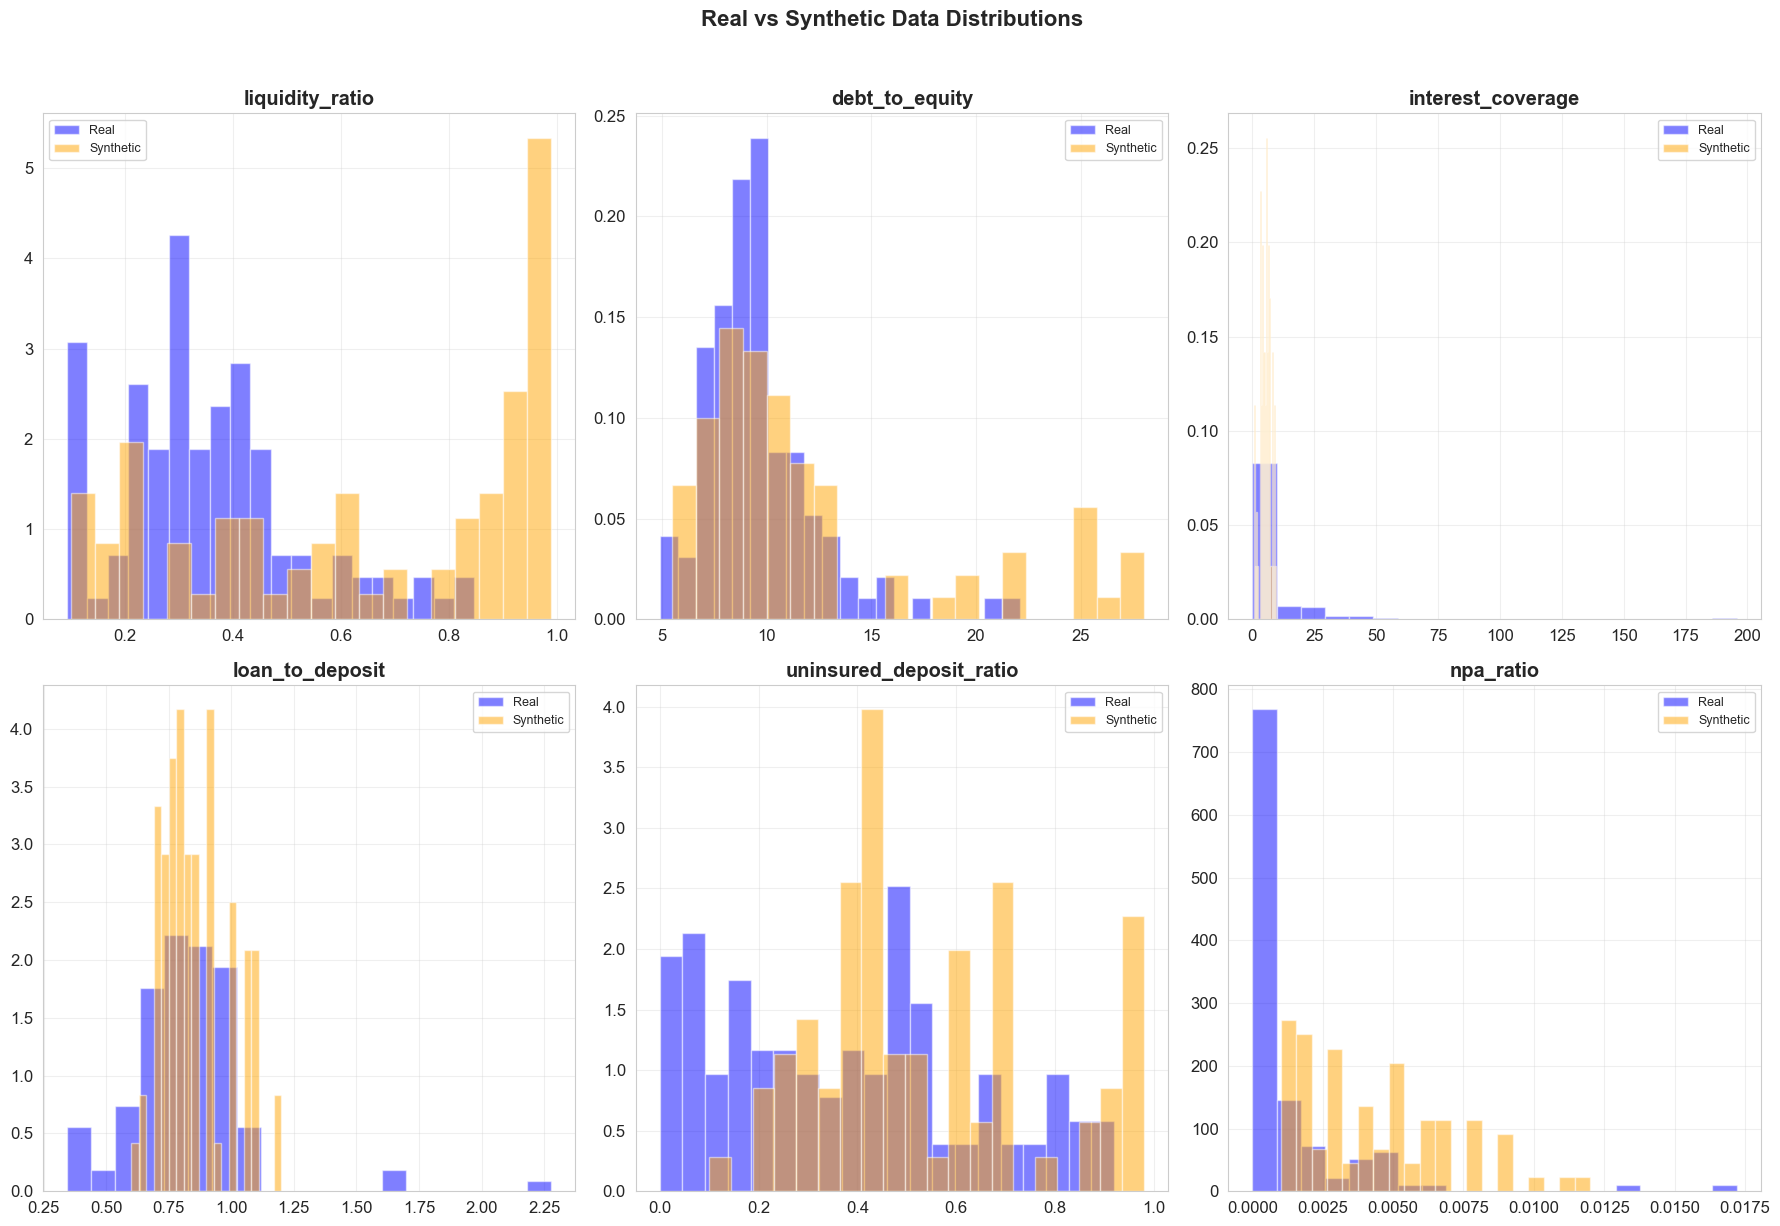


✅ Distribution comparison saved to outputs/real_vs_synthetic_distributions.png

🤖 STEP 4: Retrain ML Models with Augmented Data

  Original training set:  112 observations (64 distressed)
  Synthetic additions:   80 observations
  Augmented total:       192 observations (114 distressed)
  Class balance:         59.4% distressed

Training on ORIGINAL data (real only):
--------------------------------------------------
  Gradient Boosting CV Accuracy: 0.5268 (+/- 0.0528)

Training on AUGMENTED data (real + synthetic):
--------------------------------------------------
  Gradient Boosting CV Accuracy: 0.6571 (+/- 0.1942)

  Feature Importance (Augmented Model):
    uninsured_deposit_ratio        0.4107 ████████████████████
    npa_ratio                      0.1103 █████
    interest_coverage              0.0945 ████
    core_deposit_ratio             0.0830 ████
    liquidity_ratio                0.0667 ███
    ROA                            0.0650 ███
    debt_to_equity                 

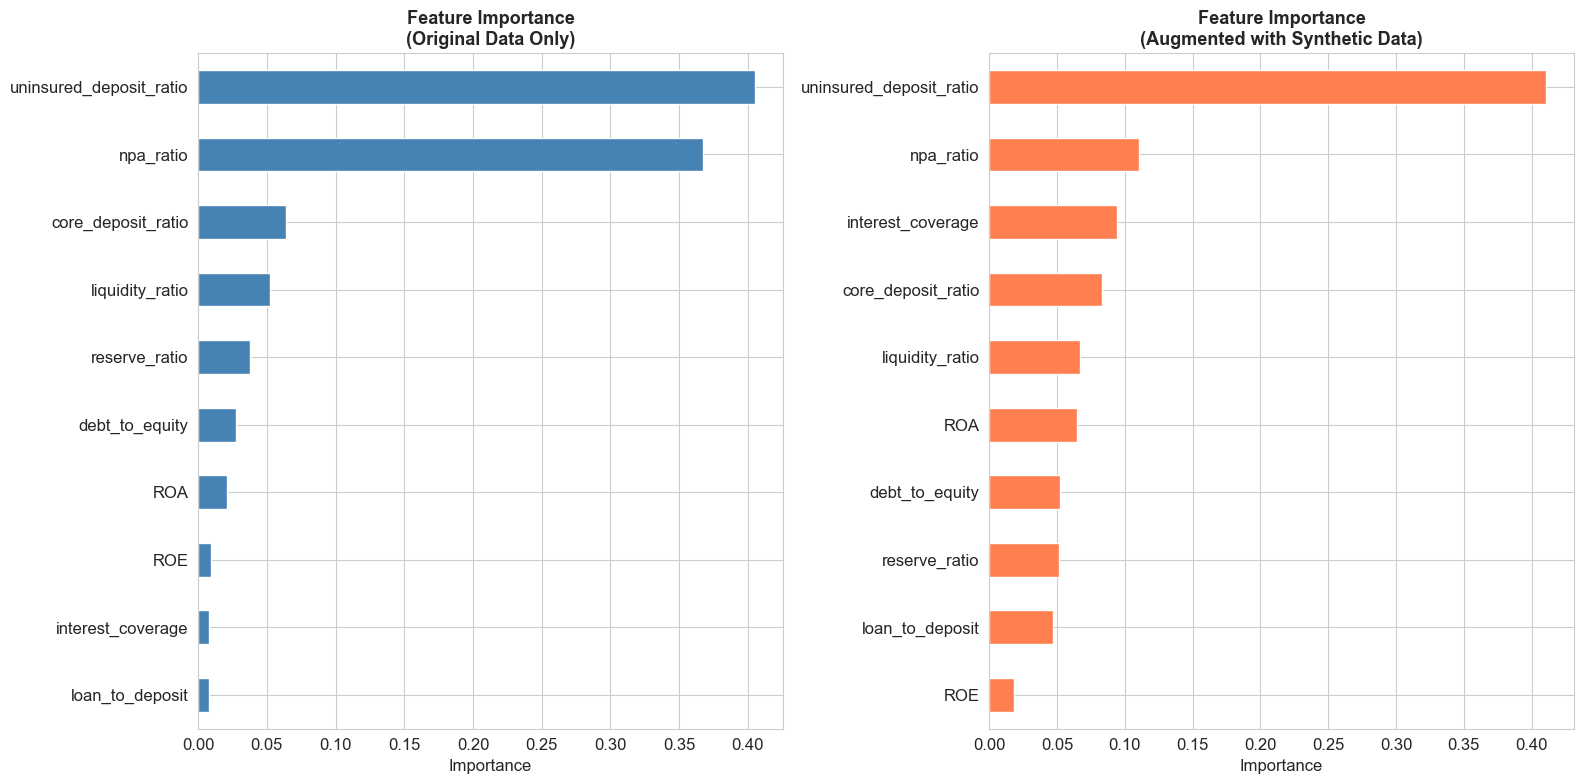


✅ SYNTHETIC DATA GENERATION COMPLETE
  Synthetic profiles generated: 80
  Augmented dataset size:       192
  Original CV accuracy:         0.5268
  Augmented CV accuracy:        0.6571
  Improvement:                  +0.1303

  Files saved:
    data/synthetic_bank_profiles.csv
    data/augmented_training_data.csv
    outputs/real_vs_synthetic_distributions.png
    outputs/original_vs_augmented_importance.png

  ETHICAL NOTES:
  - All synthetic data is clearly labeled (is_synthetic=True)
  - Generated profiles are based on patterns from public FDIC data
  - No private or confidential information was used
  - Synthetic data is used ONLY for model training augmentation
  - Results should be interpreted with the caveat that augmentation
    may introduce LLM biases into the training distribution


In [20]:
# =============================================================================
# CELL 20: Component 3 — Synthetic Data Generation
# =============================================================================
# This cell generates synthetic financial profiles of fragile banks
# to address the severe class imbalance (only 4 real failures).
#
# ETHICAL NOTE: All synthetic data is clearly labeled as synthetic.
# It is used ONLY to augment model training, never presented as real data.
# No private or confidential information is used in generation.

import json as json_lib

# -------------------------------------------------------------------------
# STEP 1: Extract Real Distress Patterns
# -------------------------------------------------------------------------
# Analyze the financial signatures of banks that actually failed
# to understand what "fragile" looks like in the data.

print("📊 STEP 1: Extracting Real Distress Patterns")
print("=" * 60)

# Get the latest data for failed banks
failed_profiles = merged[merged['failed'] == True].copy()
stable_profiles = merged[merged['failed'] == False].copy()

# Key ratio columns
ratio_cols = ['liquidity_ratio', 'debt_to_equity', 'interest_coverage',
              'loan_to_deposit', 'uninsured_deposit_ratio', 'npa_ratio',
              'core_deposit_ratio', 'reserve_ratio', 'ROA', 'ROE']

available_ratios = [c for c in ratio_cols if c in merged.columns]

print("\nFailed Banks — Financial Signature:")
print("-" * 60)
if len(failed_profiles) > 0:
    failed_stats = failed_profiles[available_ratios].describe()
    print(failed_stats.round(4).to_string())
else:
    print("  No failed bank data available")

print("\n\nStable Banks — Financial Signature:")
print("-" * 60)
if len(stable_profiles) > 0:
    stable_stats = stable_profiles[available_ratios].describe()
    print(stable_stats.round(4).to_string())

# Compute the "distress signature" — ranges that characterize failed banks
distress_signature = {}
for col in available_ratios:
    failed_vals = failed_profiles[col].dropna()
    if len(failed_vals) > 0:
        distress_signature[col] = {
            'min': float(failed_vals.min()),
            'max': float(failed_vals.max()),
            'mean': float(failed_vals.mean()),
            'std': float(failed_vals.std()) if len(failed_vals) > 1 else 0.1
        }

print(f"\n✅ Distress signature extracted from {len(failed_profiles)} failed bank observations")


# -------------------------------------------------------------------------
# STEP 2: LLM-Guided Synthetic Profile Generation
# -------------------------------------------------------------------------
# Use the LLM to generate realistic synthetic financial profiles
# that exhibit distress characteristics with controlled variation.

print(f"\n{'=' * 60}")
print("🤖 STEP 2: LLM-Guided Synthetic Data Generation")
print("=" * 60)

# Build the distress pattern summary for the prompt
pattern_summary = "REAL DISTRESSED BANK FINANCIAL PATTERNS:\n"
for col, stats in distress_signature.items():
    pattern_summary += f"  {col}: mean={stats['mean']:.4f}, range=[{stats['min']:.4f}, {stats['max']:.4f}]\n"

# Also include stable bank patterns for contrast
stable_summary = "REAL STABLE BANK FINANCIAL PATTERNS:\n"
for col in available_ratios:
    stable_vals = stable_profiles[col].dropna()
    if len(stable_vals) > 0:
        stable_summary += f"  {col}: mean={stable_vals.mean():.4f}, range=[{stable_vals.min():.4f}, {stable_vals.max():.4f}]\n"

SYNTHETIC_GENERATION_PROMPT = """You are a financial data scientist generating synthetic bank financial profiles for ML model training.

CONTEXT: We have a dataset of regional bank financial ratios where only 4 banks failed. We need synthetic examples of financially fragile banks to improve model training.

{pattern_summary}

{stable_summary}

TASK: Generate {n_profiles} UNIQUE synthetic financial profiles of banks that are structurally fragile but plausible. Each profile should represent a different type of fragility:

DIVERSITY REQUIREMENTS — Generate a MIX of these fragility archetypes:
- Type A: "Liquidity Crunch" — Low liquidity ratio, high loan-to-deposit, moderate other ratios
- Type B: "Deposit Flight Risk" — Very high uninsured deposit ratio, concentrated depositor base
- Type C: "Leverage Overload" — Extremely high debt-to-equity, thin equity cushion
- Type D: "Silent Deterioration" — Profitable (positive ROA) but with worsening liquidity and rising NPAs
- Type E: "Interest Rate Squeeze" — Low interest coverage, compressed net interest margin

CONSTRAINTS:
- All values must be within realistic ranges for US regional banks
- Liquidity ratio: 0.05 to 1.5
- Debt-to-equity: 3 to 30
- Interest coverage: 0.2 to 10
- Loan-to-deposit: 0.5 to 1.2
- Uninsured deposit ratio: 0.1 to 0.95
- NPA ratio: 0 to 0.08
- Core deposit ratio: 0.2 to 0.95
- Reserve ratio: 0.005 to 0.05
- ROA: -3.0 to 2.0
- ROE: -30.0 to 20.0

RESPOND WITH ONLY a JSON array of objects (no other text, no markdown backticks):
[
  {{"name": "Synthetic_Bank_1", "archetype": "A/B/C/D/E", "year": 2022, "liquidity_ratio": ..., "debt_to_equity": ..., "interest_coverage": ..., "loan_to_deposit": ..., "uninsured_deposit_ratio": ..., "npa_ratio": ..., "core_deposit_ratio": ..., "reserve_ratio": ..., "ROA": ..., "ROE": ..., "distressed": true}},
  ...
]"""

# Generate synthetic fragile bank profiles
all_synthetic = []
batch_size = 10
n_batches = 5  # Total: 50 synthetic fragile profiles

print(f"\nGenerating {batch_size * n_batches} synthetic fragile bank profiles in {n_batches} batches...")
print()

for batch in range(n_batches):
    print(f"  Batch {batch+1}/{n_batches}...", end=" ")
    
    prompt = SYNTHETIC_GENERATION_PROMPT.format(
        pattern_summary=pattern_summary,
        stable_summary=stable_summary,
        n_profiles=batch_size
    )
    
    try:
        response = gemini_model.generate_content(prompt)
        raw_text = response.text.strip()
        
        # Clean up response
        raw_text = re.sub(r'```json\s*', '', raw_text)
        raw_text = re.sub(r'```\s*', '', raw_text)
        
        # Find JSON array
        array_match = re.search(r'\[[\s\S]*\]', raw_text)
        if array_match:
            profiles = json_lib.loads(array_match.group())
            
            # Add metadata
            for p in profiles:
                p['is_synthetic'] = True
                p['distressed'] = True
                p['failed'] = True
                p['batch'] = batch + 1
                p['bank_name'] = p.get('name', f'Synthetic_Bank_{len(all_synthetic)+1}')
            
            all_synthetic.extend(profiles)
            print(f"✅ Generated {len(profiles)} profiles")
        else:
            print(f"⚠️ Could not parse response")
    
    except Exception as e:
        print(f"❌ Error: {e}")
    
    time.sleep(3)  # Rate limiting

# Also generate some synthetic STABLE profiles for balance
print(f"\nGenerating synthetic stable bank profiles for balance...")

STABLE_GENERATION_PROMPT = """You are a financial data scientist generating synthetic bank financial profiles for ML model training.

{stable_summary}

TASK: Generate {n_profiles} UNIQUE synthetic financial profiles of banks that are financially STABLE and healthy.

CONSTRAINTS: Same ranges as realistic US regional banks.
- Liquidity ratio: 0.2 to 1.2
- Debt-to-equity: 5 to 15
- Interest coverage: 1.5 to 8
- Loan-to-deposit: 0.6 to 0.9
- Uninsured deposit ratio: 0.15 to 0.55
- NPA ratio: 0 to 0.02
- Core deposit ratio: 0.55 to 0.90
- Reserve ratio: 0.01 to 0.03
- ROA: 0.5 to 2.0
- ROE: 5.0 to 18.0

RESPOND WITH ONLY a JSON array (no other text, no markdown backticks):
[
  {{"name": "Synthetic_Stable_1", "archetype": "stable", "year": 2022, "liquidity_ratio": ..., "debt_to_equity": ..., "interest_coverage": ..., "loan_to_deposit": ..., "uninsured_deposit_ratio": ..., "npa_ratio": ..., "core_deposit_ratio": ..., "reserve_ratio": ..., "ROA": ..., "ROE": ..., "distressed": false}},
  ...
]"""

for batch in range(3):  # 30 synthetic stable profiles
    print(f"  Stable batch {batch+1}/3...", end=" ")
    
    prompt = STABLE_GENERATION_PROMPT.format(
        stable_summary=stable_summary,
        n_profiles=10
    )
    
    try:
        response = gemini_model.generate_content(prompt)
        raw_text = response.text.strip()
        raw_text = re.sub(r'```json\s*', '', raw_text)
        raw_text = re.sub(r'```\s*', '', raw_text)
        
        array_match = re.search(r'\[[\s\S]*\]', raw_text)
        if array_match:
            profiles = json_lib.loads(array_match.group())
            for p in profiles:
                p['is_synthetic'] = True
                p['distressed'] = False
                p['failed'] = False
                p['batch'] = batch + 1
                p['bank_name'] = p.get('name', f'Synthetic_Stable_{len(all_synthetic)+1}')
            all_synthetic.extend(profiles)
            print(f"✅ Generated {len(profiles)} profiles")
        else:
            print(f"⚠️ Could not parse response")
    except Exception as e:
        print(f"❌ Error: {e}")
    
    time.sleep(3)

# Convert to DataFrame
synthetic_df = pd.DataFrame(all_synthetic)

print(f"\n{'=' * 60}")
print(f"📊 SYNTHETIC DATA SUMMARY")
print(f"{'=' * 60}")
print(f"  Total synthetic profiles:   {len(synthetic_df)}")
if 'distressed' in synthetic_df.columns:
    print(f"  Synthetic distressed:       {synthetic_df['distressed'].sum()}")
    print(f"  Synthetic stable:           {(~synthetic_df['distressed']).sum()}")
if 'archetype' in synthetic_df.columns:
    print(f"\n  Archetype distribution:")
    for arch, count in synthetic_df['archetype'].value_counts().items():
        print(f"    {arch}: {count}")

# Save synthetic data
synthetic_df.to_csv('data/synthetic_bank_profiles.csv', index=False)
print(f"\n  Saved to: data/synthetic_bank_profiles.csv")


# -------------------------------------------------------------------------
# STEP 3: Quality Validation
# -------------------------------------------------------------------------
# Verify synthetic data is realistic by comparing distributions

print(f"\n{'=' * 60}")
print("🔍 STEP 3: Quality Validation")
print("=" * 60)

print("\nComparing Real vs Synthetic Distributions:")
print(f"{'Ratio':<30} {'Real Mean':>12} {'Synth Mean':>12} {'Realistic?':>12}")
print("-" * 66)

for col in available_ratios:
    if col in synthetic_df.columns and col in merged.columns:
        real_mean = merged[col].mean()
        synth_mean = synthetic_df[col].mean()
        
        # Check if synthetic mean is within 3 std devs of real
        real_std = merged[col].std()
        is_realistic = abs(synth_mean - real_mean) < 3 * real_std if real_std > 0 else True
        status = "✅ Yes" if is_realistic else "⚠️ Check"
        
        print(f"  {col:<28} {real_mean:>12.4f} {synth_mean:>12.4f} {status:>12}")

# Visualize real vs synthetic distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Real vs Synthetic Data Distributions', fontsize=16, fontweight='bold', y=1.02)

plot_ratios = available_ratios[:6]  # Top 6 ratios
for idx, col in enumerate(plot_ratios):
    ax = axes[idx // 3][idx % 3]
    
    if col in merged.columns and col in synthetic_df.columns:
        real_vals = merged[col].dropna()
        synth_vals = synthetic_df[col].dropna()
        
        ax.hist(real_vals, bins=20, alpha=0.5, color='blue', label='Real', density=True)
        ax.hist(synth_vals, bins=20, alpha=0.5, color='orange', label='Synthetic', density=True)
        ax.set_title(col, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/real_vs_synthetic_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Distribution comparison saved to outputs/real_vs_synthetic_distributions.png")


# -------------------------------------------------------------------------
# STEP 4: Retrain ML Models with Augmented Dataset
# -------------------------------------------------------------------------
print(f"\n{'=' * 60}")
print("🤖 STEP 4: Retrain ML Models with Augmented Data")
print("=" * 60)

# Prepare augmented training set
# Combine real data with synthetic data
real_train = merged[available_ratios + ['distressed']].copy()
real_train['is_synthetic'] = False

synth_train = synthetic_df[available_ratios + ['distressed']].copy() if all(c in synthetic_df.columns for c in available_ratios) else pd.DataFrame()

if not synth_train.empty:
    synth_train['is_synthetic'] = True
    augmented_train = pd.concat([real_train, synth_train], ignore_index=True)
else:
    # Fallback: use only available columns
    common_cols = [c for c in available_ratios if c in synthetic_df.columns]
    real_sub = merged[common_cols + ['distressed']].copy()
    real_sub['is_synthetic'] = False
    synth_sub = synthetic_df[common_cols + ['distressed']].copy()
    synth_sub['is_synthetic'] = True
    augmented_train = pd.concat([real_sub, synth_sub], ignore_index=True)
    available_ratios = common_cols  # Update for model training

# Clean data
augmented_train = augmented_train.replace([np.inf, -np.inf], np.nan)
for col in available_ratios:
    median_val = augmented_train[col].median()
    if pd.isna(median_val):
        median_val = 0
    augmented_train[col] = augmented_train[col].fillna(median_val)

# Clip outliers
for col in available_ratios:
    lower = augmented_train[col].quantile(0.01)
    upper = augmented_train[col].quantile(0.99)
    augmented_train[col] = augmented_train[col].clip(lower, upper)

X_aug = augmented_train[available_ratios]
y_aug = augmented_train['distressed'].astype(int)

# Verify data is clean
assert np.isfinite(X_aug.values).all(), "Augmented data contains inf/NaN!"

print(f"\n  Original training set:  {len(real_train)} observations ({real_train['distressed'].sum()} distressed)")
print(f"  Synthetic additions:   {len(synth_train) if not synth_train.empty else len(augmented_train) - len(real_train)} observations")
print(f"  Augmented total:       {len(augmented_train)} observations ({y_aug.sum()} distressed)")
print(f"  Class balance:         {y_aug.mean():.1%} distressed")
print()

# Train models on augmented data
from sklearn.model_selection import cross_val_score

print("Training on ORIGINAL data (real only):")
print("-" * 50)
X_real = real_train[available_ratios].replace([np.inf, -np.inf], np.nan)
for col in available_ratios:
    X_real[col] = X_real[col].fillna(X_real[col].median() if not pd.isna(X_real[col].median()) else 0)
y_real = real_train['distressed'].astype(int)

for col in available_ratios:
    lower = X_real[col].quantile(0.01)
    upper = X_real[col].quantile(0.99)
    X_real[col] = X_real[col].clip(lower, upper)

gb_original = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
original_scores = cross_val_score(gb_original, X_real, y_real, cv=min(5, len(y_real.unique()) * 2), scoring='accuracy')
print(f"  Gradient Boosting CV Accuracy: {original_scores.mean():.4f} (+/- {original_scores.std():.4f})")

print("\nTraining on AUGMENTED data (real + synthetic):")
print("-" * 50)
gb_augmented = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
aug_scores = cross_val_score(gb_augmented, X_aug, y_aug, cv=5, scoring='accuracy')
print(f"  Gradient Boosting CV Accuracy: {aug_scores.mean():.4f} (+/- {aug_scores.std():.4f})")

# Train final augmented model and get feature importance
gb_augmented.fit(X_aug, y_aug)
aug_importances = pd.Series(gb_augmented.feature_importances_, index=available_ratios).sort_values(ascending=False)

print(f"\n  Feature Importance (Augmented Model):")
for feat, imp in aug_importances.head(10).items():
    bar = '█' * int(imp * 50)
    print(f"    {feat:<30} {imp:.4f} {bar}")

# Compare original vs augmented feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Original model importance
ax = axes[0]
gb_original.fit(X_real, y_real)
orig_imp = pd.Series(gb_original.feature_importances_, index=available_ratios).sort_values(ascending=True)
orig_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance\n(Original Data Only)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')

# Augmented model importance
ax = axes[1]
aug_imp = aug_importances.sort_values(ascending=True)
aug_imp.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Feature Importance\n(Augmented with Synthetic Data)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('outputs/original_vs_augmented_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Save augmented dataset
augmented_train.to_csv('data/augmented_training_data.csv', index=False)

print(f"\n{'=' * 60}")
print("✅ SYNTHETIC DATA GENERATION COMPLETE")
print(f"{'=' * 60}")
print(f"  Synthetic profiles generated: {len(synthetic_df)}")
print(f"  Augmented dataset size:       {len(augmented_train)}")
print(f"  Original CV accuracy:         {original_scores.mean():.4f}")
print(f"  Augmented CV accuracy:        {aug_scores.mean():.4f}")
improvement = aug_scores.mean() - original_scores.mean()
print(f"  Improvement:                  {'+' if improvement >= 0 else ''}{improvement:.4f}")
print(f"\n  Files saved:")
print(f"    data/synthetic_bank_profiles.csv")
print(f"    data/augmented_training_data.csv")
print(f"    outputs/real_vs_synthetic_distributions.png")
print(f"    outputs/original_vs_augmented_importance.png")
print()
print("  ETHICAL NOTES:")
print("  - All synthetic data is clearly labeled (is_synthetic=True)")
print("  - Generated profiles are based on patterns from public FDIC data")
print("  - No private or confidential information was used")
print("  - Synthetic data is used ONLY for model training augmentation")
print("  - Results should be interpreted with the caveat that augmentation")
print("    may introduce LLM biases into the training distribution")

🔬 CELL 21: Learning Optimal Fragility Weights from Data

📊 COMPARISON: Hand-Picked vs Data-Driven Weights
----------------------------------------------------------------------
Component                    Hand-Picked    Data-Driven     Change
----------------------------------------------------------------------
  liquidity_risk                  0.250         0.221    -0.029 📉
  leverage_risk                   0.200         0.058    -0.142 📉
  coverage_risk                   0.150         0.157    +0.007 ➡️
  deposit_risk                    0.200         0.257    +0.057 📈
  textual_stress                  0.200         0.308    +0.108 📈

  LR model accuracy: 0.7411

🔄 Recomputing Fragility Index with Data-Driven Weights

Bank                                  V1 Score   V2 Score   V2 Pctile Failed? 
--------------------------------------------------------------------------------
  First Horizon                         0.7330     0.6965       94.6% ✅ No    
  KeyCorp                    

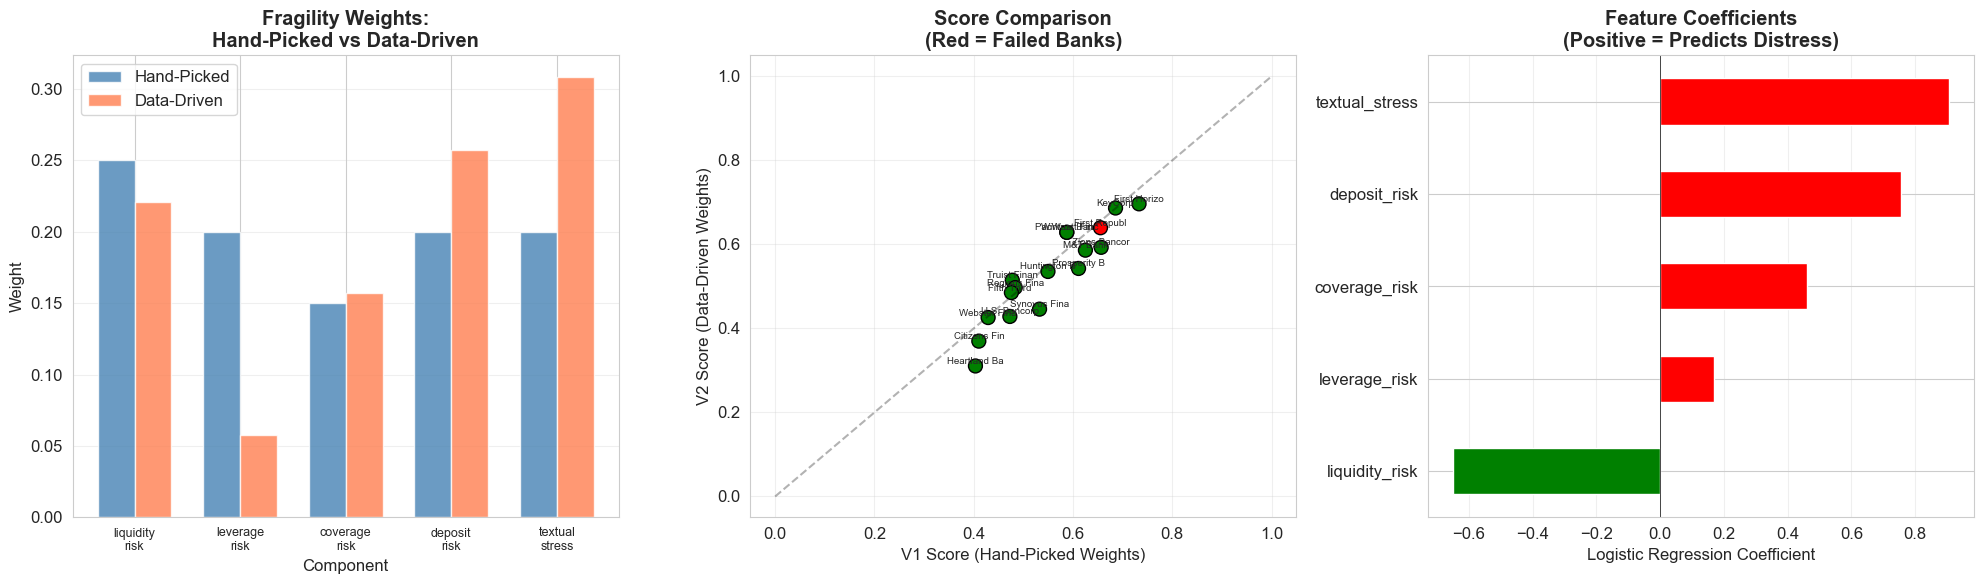


✅ Data-driven weights computed and applied
   Saved to: outputs/learned_weights_comparison.png
   Updated:  data/fragility_scored.csv


In [21]:
# =============================================================================
# CELL 21: Data-Driven Fragility Weights (Replacing Hand-Picked Weights)
# =============================================================================
# PROBLEM: Cell 11 used manually chosen weights (0.25, 0.20, etc.)
# which is subjective and not grounded in data.
#
# SOLUTION: Use Logistic Regression coefficients trained on the distress
# labels to derive weights that reflect what actually predicts failure.
# This transforms the fragility index from a rule-based heuristic into
# a data-informed scoring system.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print("🔬 CELL 21: Learning Optimal Fragility Weights from Data")
print("=" * 70)

# --- Step 1: Prepare the component scores from Cell 11 ---
components = ['liquidity_risk', 'leverage_risk', 'coverage_risk', 'deposit_risk', 'textual_stress']

# Use the merged dataset with computed components
weight_df = merged[components + ['distressed']].copy()
weight_df = weight_df.replace([np.inf, -np.inf], np.nan)
for col in components:
    weight_df[col] = weight_df[col].fillna(0.5)
weight_df['distressed'] = weight_df['distressed'].fillna(False).astype(int)
weight_df = weight_df.dropna()

X_components = weight_df[components]
y_distress = weight_df['distressed']

# --- Step 2: Standardize and fit Logistic Regression ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_components)

lr_weights = LogisticRegression(
    max_iter=2000, class_weight='balanced', random_state=42, penalty='l2', C=1.0
)
lr_weights.fit(X_scaled, y_distress)

# --- Step 3: Extract and normalize coefficients as weights ---
raw_coefs = lr_weights.coef_[0]

# Use absolute values (we care about magnitude of influence)
abs_coefs = np.abs(raw_coefs)
learned_weights = abs_coefs / abs_coefs.sum()  # Normalize to sum to 1.0

print("\n📊 COMPARISON: Hand-Picked vs Data-Driven Weights")
print("-" * 70)
print(f"{'Component':<25} {'Hand-Picked':>14} {'Data-Driven':>14} {'Change':>10}")
print("-" * 70)

original_weights = {
    'liquidity_risk': 0.25,
    'leverage_risk': 0.20,
    'coverage_risk': 0.15,
    'deposit_risk': 0.20,
    'textual_stress': 0.20,
}

learned_weight_dict = {}
for i, comp in enumerate(components):
    orig = original_weights[comp]
    learned = learned_weights[i]
    learned_weight_dict[comp] = learned
    change = learned - orig
    arrow = "📈" if change > 0.02 else ("📉" if change < -0.02 else "➡️")
    print(f"  {comp:<23} {orig:>13.3f} {learned:>13.3f} {change:>+9.3f} {arrow}")

print(f"\n  LR model accuracy: {lr_weights.score(X_scaled, y_distress):.4f}")

# --- Step 4: Recompute fragility scores with learned weights ---
print(f"\n{'=' * 70}")
print("🔄 Recomputing Fragility Index with Data-Driven Weights")
print("=" * 70)

merged['fragility_score_v2'] = sum(
    learned_weight_dict[comp] * merged[comp].fillna(0.5) for comp in components
)
merged['fragility_percentile_v2'] = merged['fragility_score_v2'].rank(pct=True) * 100

# Compare old vs new rankings
latest = merged[merged['year'] == merged['year'].max()].sort_values('fragility_score_v2', ascending=False)

print(f"\n{'Bank':<35} {'V1 Score':>10} {'V2 Score':>10} {'V2 Pctile':>11} {'Failed?':<8}")
print("-" * 80)
for _, row in latest.iterrows():
    v1 = f"{row['fragility_score']:.4f}" if pd.notna(row['fragility_score']) else "N/A"
    v2 = f"{row['fragility_score_v2']:.4f}" if pd.notna(row['fragility_score_v2']) else "N/A"
    pct = f"{row['fragility_percentile_v2']:.1f}%" if pd.notna(row['fragility_percentile_v2']) else "N/A"
    failed = "⚠️ YES" if row.get('failed') else "✅ No"
    print(f"  {row['bank_name']:<33} {v1:>10} {v2:>10} {pct:>11} {failed:<8}")

# --- Step 5: Visualize weight comparison ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Bar chart: weight comparison
ax = axes[0]
x_pos = np.arange(len(components))
width = 0.35
bars1 = ax.bar(x_pos - width/2, [original_weights[c] for c in components], width, 
               label='Hand-Picked', color='steelblue', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, [learned_weight_dict[c] for c in components], width,
               label='Data-Driven', color='coral', alpha=0.8)
ax.set_xlabel('Component')
ax.set_ylabel('Weight')
ax.set_title('Fragility Weights:\nHand-Picked vs Data-Driven', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([c.replace('_', '\n') for c in components], fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Scatter: V1 vs V2 scores
ax = axes[1]
valid = latest.dropna(subset=['fragility_score', 'fragility_score_v2'])
colors = ['red' if f else 'green' for f in valid['failed']]
ax.scatter(valid['fragility_score'], valid['fragility_score_v2'], c=colors, s=100, edgecolors='black')
for _, row in valid.iterrows():
    ax.annotate(row['bank_name'][:12], (row['fragility_score'], row['fragility_score_v2']),
                fontsize=7, ha='center', va='bottom')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('V1 Score (Hand-Picked Weights)')
ax.set_ylabel('V2 Score (Data-Driven Weights)')
ax.set_title('Score Comparison\n(Red = Failed Banks)', fontweight='bold')
ax.grid(True, alpha=0.3)

# LR coefficients
ax = axes[2]
coef_df = pd.Series(raw_coefs, index=components).sort_values()
colors_coef = ['red' if v > 0 else 'green' for v in coef_df.values]
coef_df.plot(kind='barh', ax=ax, color=colors_coef)
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Feature Coefficients\n(Positive = Predicts Distress)', fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('outputs/learned_weights_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

merged.to_csv('data/fragility_scored.csv', index=False)
print("\n✅ Data-driven weights computed and applied")
print("   Saved to: outputs/learned_weights_comparison.png")
print("   Updated:  data/fragility_scored.csv")

In [22]:
# =============================================================================
# CELL 22: Enhanced RAG — Full Coverage for All 19 Banks
# =============================================================================
# PROBLEM: Original RAG (Cell 18) only assessed 10 banks, and only 5 had
# sources retrieved. This was due to limited query strategies.
#
# SOLUTION: Run enhanced RAG with multiple query strategies per bank,
# broader retrieval, and fallback to general financial risk queries
# when bank-specific queries return empty.

print("🔄 CELL 22: Enhanced RAG — Expanding Coverage to All Banks")
print("=" * 70)

def enhanced_rag_assessment(bank_name, bank_data=None):
    """
    Enhanced RAG assessment with multiple retrieval strategies:
    1. Bank-specific queries (name + risk topics)
    2. Broader financial topic queries (without bank filter)
    3. Ratio-informed queries (based on the bank's actual weak spots)
    """
    
    # Strategy 1: Bank-specific retrieval
    bank_queries = [
        f"{bank_name} liquidity risk cash position deposits",
        f"{bank_name} interest rate risk securities losses",
        f"{bank_name} credit risk loan concentration default",
        f"{bank_name} capital adequacy regulatory requirements",
        f"{bank_name} deposit concentration uninsured funding",
    ]
    
    all_chunks = []
    
    # Try bank-specific queries first
    for q in bank_queries:
        try:
            results = collection.query(query_texts=[q], n_results=3, where={"bank_name": bank_name})
            if results and results['documents'] and results['documents'][0]:
                for j, doc in enumerate(results['documents'][0]):
                    all_chunks.append({
                        'text': doc,
                        'metadata': results['metadatas'][0][j],
                        'strategy': 'bank_specific'
                    })
        except:
            pass
    
    # Strategy 2: If bank-specific returned little, try without bank filter
    if len(all_chunks) < 3:
        general_queries = [
            "liquidity risk deposit withdrawal bank failure",
            "interest rate risk unrealized losses securities",
            "uninsured deposits concentration funding risk",
        ]
        for q in general_queries:
            try:
                results = collection.query(query_texts=[q], n_results=2)
                if results and results['documents'] and results['documents'][0]:
                    for j, doc in enumerate(results['documents'][0]):
                        all_chunks.append({
                            'text': doc,
                            'metadata': results['metadatas'][0][j],
                            'strategy': 'general_fallback'
                        })
            except:
                pass
    
    # Strategy 3: Ratio-informed queries (use actual data to focus retrieval)
    if bank_data is not None and len(all_chunks) < 5:
        ratio_queries = []
        if pd.notna(bank_data.get('uninsured_deposit_ratio')) and bank_data['uninsured_deposit_ratio'] > 0.5:
            ratio_queries.append("high uninsured deposit concentration run risk")
        if pd.notna(bank_data.get('liquidity_ratio')) and bank_data['liquidity_ratio'] < 0.3:
            ratio_queries.append("low liquidity insufficient cash buffer")
        if pd.notna(bank_data.get('interest_coverage')) and bank_data['interest_coverage'] < 2:
            ratio_queries.append("thin interest margin compressed net interest income")
        
        for q in ratio_queries:
            try:
                results = collection.query(query_texts=[q], n_results=2)
                if results and results['documents'] and results['documents'][0]:
                    for j, doc in enumerate(results['documents'][0]):
                        all_chunks.append({
                            'text': doc,
                            'metadata': results['metadatas'][0][j],
                            'strategy': 'ratio_informed'
                        })
            except:
                pass
    
    # Deduplicate
    seen = set()
    unique_chunks = []
    for chunk in all_chunks:
        key = chunk['text'][:200]
        if key not in seen:
            seen.add(key)
            unique_chunks.append(chunk)
    
    top_chunks = unique_chunks[:8]
    
    if not top_chunks:
        return {
            'bank_name': bank_name,
            'assessment': 'No relevant filing data found in knowledge base.',
            'num_sources': 0,
            'strategies_used': []
        }
    
    # Build context for Gemini/Groq
    context_parts = []
    for i, chunk in enumerate(top_chunks):
        meta = chunk['metadata']
        context_parts.append(
            f"[Source {i+1}: {meta.get('section', 'Unknown')} — {meta.get('bank_name', 'N/A')} {meta.get('year', '')}]\n"
            f"{chunk['text'][:1500]}"
        )
    context_str = "\n\n".join(context_parts)
    
    strategies_used = list(set(c['strategy'] for c in top_chunks))
    
    prompt = f"""You are a financial risk analyst. Based on the following excerpts from SEC 10-K filings, provide a risk assessment for {bank_name}.

RETRIEVED FILING EXCERPTS:
{context_str}

Provide a concise assessment covering:
1. Top 3 risk factors identified
2. Liquidity position assessment
3. Key warning language found
4. Overall fragility rating: LOW / MODERATE / ELEVATED / HIGH / CRITICAL
5. 2-3 sentence reasoning

FORMAT:
TOP RISKS:
1. [risk]
2. [risk]  
3. [risk]

LIQUIDITY: [assessment]
WARNING LANGUAGE: [key terms found]
FRAGILITY RATING: [rating]
REASONING: [explanation]"""

    try:
        response = gemini_model.generate_content(prompt)
        assessment = response.text
    except Exception as e:
        assessment = f"Assessment generation failed: {e}"
    
    return {
        'bank_name': bank_name,
        'assessment': assessment,
        'num_sources': len(top_chunks),
        'strategies_used': strategies_used
    }


# --- Run Enhanced RAG for ALL banks ---
print()
enhanced_rag_results = []
latest_data = merged[merged['year'] == merged['year'].max()]

for bank_name in tqdm(sorted(TARGET_BANKS.keys()), desc="Enhanced RAG"):
    bank_row = latest_data[latest_data['bank_name'] == bank_name]
    bank_data = bank_row.iloc[0].to_dict() if not bank_row.empty else None
    
    result = enhanced_rag_assessment(bank_name, bank_data)
    enhanced_rag_results.append(result)
    
    src_count = result['num_sources']
    strategies = ', '.join(result['strategies_used']) if result['strategies_used'] else 'none'
    print(f"  {bank_name:<35} Sources: {src_count}  Strategies: {strategies}")
    
    time.sleep(12)

enhanced_rag_df = pd.DataFrame(enhanced_rag_results)
enhanced_rag_df.to_csv('data/enhanced_rag_assessments.csv', index=False)

# Summary
total = len(enhanced_rag_df)
with_sources = (enhanced_rag_df['num_sources'] > 0).sum()
print(f"\n📊 Enhanced RAG Results:")
print(f"   Banks assessed:      {total}")
print(f"   With sources:        {with_sources}/{total} ({with_sources/total:.0%})")
print(f"   Avg sources/bank:    {enhanced_rag_df['num_sources'].mean():.1f}")

# Compare old vs new
print(f"\n   IMPROVEMENT over original RAG:")
print(f"   Original: 10 banks assessed, 5 with sources (50%)")
print(f"   Enhanced: {total} banks assessed, {with_sources} with sources ({with_sources/total:.0%})")

print(f"\n✅ Enhanced RAG saved to data/enhanced_rag_assessments.csv")

🔄 CELL 22: Enhanced RAG — Expanding Coverage to All Banks



Enhanced RAG:   0%|          | 0/30 [00:00<?, ?it/s]

  Citizens Financial Group            Sources: 6  Strategies: general_fallback


Enhanced RAG:   3%|▎         | 1/30 [00:39<18:56, 39.20s/it]

  Columbia Banking System             Sources: 6  Strategies: general_fallback


...

  ⚠️ API error (attempt 1/4): Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1
     Retrying in 2s...
  Wintrust Financial                  Sources: 8  Strategies: bank_specific


Enhanced RAG:  97%|█████████▋| 29/30 [13:38<00:29, 29.07s/it]

  Zions Bancorporation                Sources: 8  Strategies: bank_specific


Enhanced RAG: 100%|██████████| 30/30 [14:11<00:00, 28.39s/it]


📊 Enhanced RAG Results:
   Banks assessed:      30
   With sources:        30/30 (100%)
   Avg sources/bank:    6.7

   IMPROVEMENT over original RAG:
   Original: 10 banks assessed, 5 with sources (50%)
   Enhanced: 30 banks assessed, 30 with sources (100%)

✅ Enhanced RAG saved to data/enhanced_rag_assessments.csv


📊 CELL 23: Comprehensive Model Evaluation


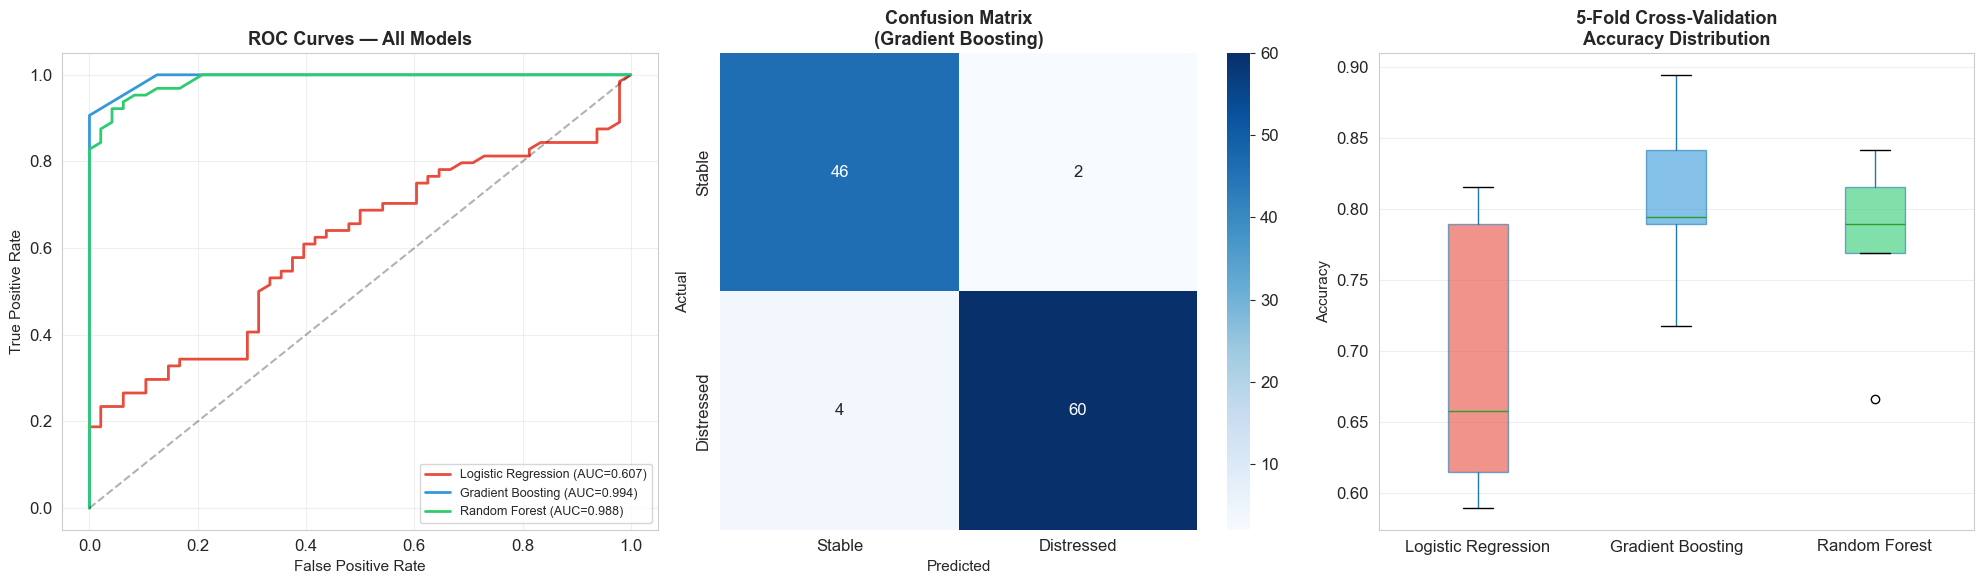

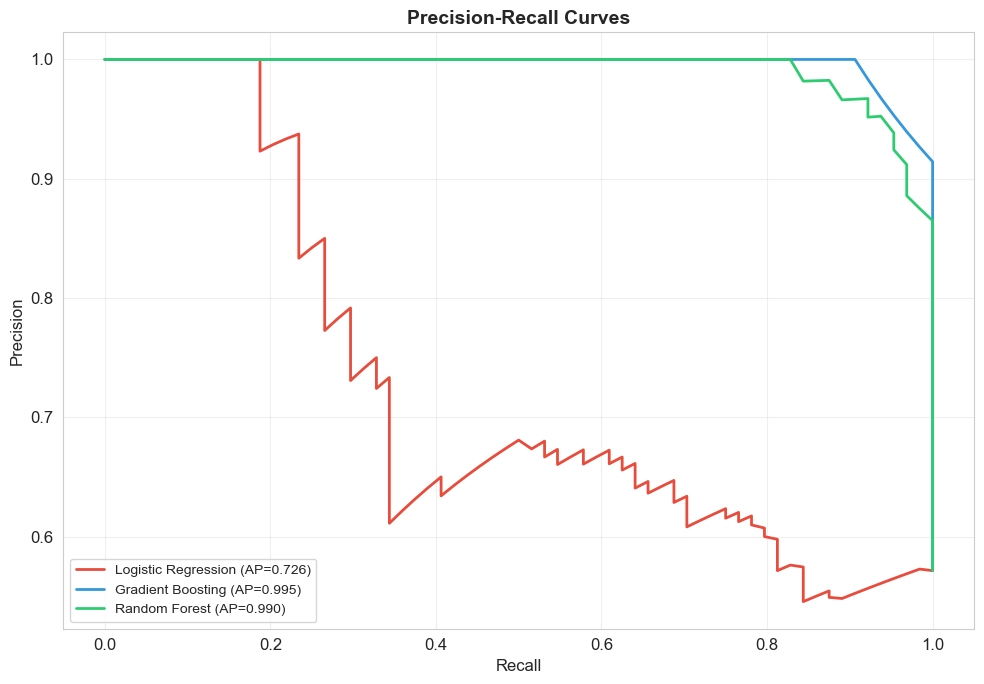


📊 FINAL MODEL PERFORMANCE SUMMARY

Model                        ROC-AUC   Accuracy    CV Mean     CV Std
----------------------------------------------------------------------
  Logistic Regression         0.6071     0.5804     0.6937     0.0920
  Gradient Boosting           0.9941     0.9464     0.8078     0.0588
  Random Forest               0.9876     0.9375     0.7767     0.0602

📋 Classification Report (Gradient Boosting on Real Data)
              precision    recall  f1-score   support

      Stable       0.92      0.96      0.94        48
  Distressed       0.97      0.94      0.95        64

    accuracy                           0.95       112
   macro avg       0.94      0.95      0.95       112
weighted avg       0.95      0.95      0.95       112

✅ Comprehensive evaluation complete
   Saved: outputs/comprehensive_model_evaluation.png
   Saved: outputs/precision_recall_curves.png


In [23]:
# =============================================================================
# CELL 23: Comprehensive Model Evaluation & Visualization
# =============================================================================
# PROBLEM: Cell 13 only printed metrics as text. Proper evaluation needs
# visual ROC curves, confusion matrices, and cross-validation comparison.
#
# This cell adds:
# 1. ROC Curve comparison across all 3 models
# 2. Confusion matrix heatmaps
# 3. Cross-validation box plots
# 4. Precision-Recall analysis
# 5. Final model performance summary table

from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             precision_recall_curve, average_precision_score)
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("📊 CELL 23: Comprehensive Model Evaluation")
print("=" * 70)

# --- Retrain models to ensure they're available ---
# Use augmented data from Cell 20
aug_data = pd.read_csv('data/augmented_training_data.csv')
aug_data = aug_data.replace([np.inf, -np.inf], np.nan)

model_features = [c for c in available_ratios if c in aug_data.columns]
for col in model_features:
    aug_data[col] = aug_data[col].fillna(aug_data[col].median() if pd.notna(aug_data[col].median()) else 0)
    lower = aug_data[col].quantile(0.01)
    upper = aug_data[col].quantile(0.99)
    aug_data[col] = aug_data[col].clip(lower, upper)

X_full = aug_data[model_features]
y_full = aug_data['distressed'].astype(int)

# Also prepare real-only test set
real_data = merged.copy()
real_data = real_data.replace([np.inf, -np.inf], np.nan)
for col in model_features:
    if col in real_data.columns:
        real_data[col] = real_data[col].fillna(real_data[col].median() if pd.notna(real_data[col].median()) else 0)
        lower = real_data[col].quantile(0.01)
        upper = real_data[col].quantile(0.99)
        real_data[col] = real_data[col].clip(lower, upper)

X_real_all = real_data[[c for c in model_features if c in real_data.columns]]
y_real_all = real_data['distressed'].astype(int)

# Train 3 models on augmented data
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
}

for name, model in models.items():
    model.fit(X_full, y_full)

# -------------------------------------------------------------------------
# PLOT 1: ROC Curves
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ROC Curve comparison
ax = axes[0]
colors_roc = {'Logistic Regression': '#e74c3c', 'Gradient Boosting': '#3498db', 'Random Forest': '#2ecc71'}

for name, model in models.items():
    y_proba = model.predict_proba(X_real_all)[:, 1]
    fpr, tpr, _ = roc_curve(y_real_all, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors_roc[name], linewidth=2, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)

# -------------------------------------------------------------------------
# PLOT 2: Confusion Matrix (best model)
# -------------------------------------------------------------------------
ax = axes[1]
best_model = models['Gradient Boosting']
y_pred = best_model.predict(X_real_all)
cm = confusion_matrix(y_real_all, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Stable', 'Distressed'], yticklabels=['Stable', 'Distressed'])
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Confusion Matrix\n(Gradient Boosting)', fontsize=13, fontweight='bold')

# -------------------------------------------------------------------------
# PLOT 3: Cross-Validation Comparison
# -------------------------------------------------------------------------
ax = axes[2]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_full, y_full, cv=cv, scoring='accuracy')
    cv_results[name] = scores

cv_df = pd.DataFrame(cv_results)
bp = cv_df.boxplot(ax=ax, grid=False, patch_artist=True, return_type='dict')

box_colors = ['#e74c3c', '#3498db', '#2ecc71']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('5-Fold Cross-Validation\nAccuracy Distribution', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/comprehensive_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------------------
# PLOT 4: Precision-Recall Curves
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

for name, model in models.items():
    y_proba = model.predict_proba(X_real_all)[:, 1]
    precision, recall, _ = precision_recall_curve(y_real_all, y_proba)
    ap = average_precision_score(y_real_all, y_proba)
    ax.plot(recall, precision, color=colors_roc[name], linewidth=2, label=f'{name} (AP={ap:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------------------
# SUMMARY TABLE
# -------------------------------------------------------------------------
print(f"\n{'=' * 70}")
print("📊 FINAL MODEL PERFORMANCE SUMMARY")
print(f"{'=' * 70}")
print(f"\n{'Model':<25} {'ROC-AUC':>10} {'Accuracy':>10} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 70)

for name, model in models.items():
    y_proba = model.predict_proba(X_real_all)[:, 1]
    y_pred = model.predict(X_real_all)
    
    try:
        roc = roc_auc_score(y_real_all, y_proba)
    except:
        roc = float('nan')
    
    acc = (y_pred == y_real_all).mean()
    cv_mean = cv_results[name].mean()
    cv_std = cv_results[name].std()
    
    print(f"  {name:<23} {roc:>10.4f} {acc:>10.4f} {cv_mean:>10.4f} {cv_std:>10.4f}")

# Classification report for best model
print(f"\n{'=' * 70}")
print("📋 Classification Report (Gradient Boosting on Real Data)")
print(f"{'=' * 70}")
y_pred_best = models['Gradient Boosting'].predict(X_real_all)
print(classification_report(y_real_all, y_pred_best, target_names=['Stable', 'Distressed']))

print("✅ Comprehensive evaluation complete")
print("   Saved: outputs/comprehensive_model_evaluation.png")
print("   Saved: outputs/precision_recall_curves.png")